In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "1996435"

MATCH_FILE = DATA_DIR / "1996435_match.json"
TRACKING_FILE = DATA_DIR / "1996435_tracking_extrapolated.jsonl"
EVENTS_FILE = DATA_DIR / "1996435_dynamic_events.csv"
PHASES_FILE = DATA_DIR / "1996435_phases_of_play.csv"

In [3]:
print("Match:", MATCH_FILE.exists())
print("Tracking:", TRACKING_FILE.exists())
print("Events:", EVENTS_FILE.exists())
print("Phases:", PHASES_FILE.exists())


Match: True
Tracking: True
Events: True
Phases: True


In [5]:
with open(MATCH_FILE, "r", encoding="utf-8") as f:
    match = json.load(f)

In [7]:
type(match)

dict

In [8]:
match["id"]

1996435

In [9]:
match.keys()

dict_keys(['id', 'home_team_score', 'away_team_score', 'date_time', 'stadium', 'home_team', 'home_team_kit', 'away_team', 'away_team_kit', 'home_team_coach', 'away_team_coach', 'home_team_playing_time', 'away_team_playing_time', 'competition_edition', 'match_periods', 'competition_round', 'referees', 'players', 'status', 'home_team_side', 'ball', 'pitch_length', 'pitch_width'])

In [10]:
list(match.keys())

['id',
 'home_team_score',
 'away_team_score',
 'date_time',
 'stadium',
 'home_team',
 'home_team_kit',
 'away_team',
 'away_team_kit',
 'home_team_coach',
 'away_team_coach',
 'home_team_playing_time',
 'away_team_playing_time',
 'competition_edition',
 'match_periods',
 'competition_round',
 'referees',
 'players',
 'status',
 'home_team_side',
 'ball',
 'pitch_length',
 'pitch_width']

In [11]:
match["home_team"]

{'id': 869,
 'name': 'Sydney Football Club',
 'short_name': 'Sydney FC',
 'acronym': 'SYD'}

In [12]:
match["away_team"]

{'id': 866,
 'name': 'Adelaide United Football Club',
 'short_name': 'Adelaide United',
 'acronym': 'ADE'}

In [13]:
len(match["players"])


36

In [14]:
match["players"][0]

{'player_role': {'id': 11,
  'position_group': 'Midfield',
  'name': 'Attacking Midfield',
  'acronym': 'AM'},
 'start_time': '01:24:41',
 'end_time': None,
 'number': 44,
 'yellow_card': 0,
 'red_card': 0,
 'injured': False,
 'goal': 0,
 'own_goal': 0,
 'playing_time': {'total': {'minutes_tip': 3.3,
   'minutes_otip': 1.78,
   'start_frame': 51840,
   'end_frame': 57619,
   'minutes_played': 9.63,
   'minutes_played_regular_time': 9.63},
  'by_period': [{'name': 'period_2',
    'minutes_tip': 3.3,
    'minutes_otip': 1.78,
    'start_frame': 51840,
    'end_frame': 57619,
    'minutes_played': 9.63}]},
 'team_player_id': 1503711,
 'team_id': 866,
 'id': 962802,
 'first_name': 'Ryan',
 'last_name': 'White',
 'short_name': 'R. White',
 'birthday': '2004-05-23',
 'trackable_object': 964365,
 'gender': 'male'}

In [15]:
with open(TRACKING_FILE, "r", encoding="utf-8") as f:
    first_line = f.readline()

first_frame = json.loads(first_line)

In [16]:
type(first_frame)

dict

In [17]:
list(first_frame.keys())

['frame',
 'timestamp',
 'period',
 'ball_data',
 'possession',
 'image_corners_projection',
 'player_data']

In [18]:
import pprint

In [19]:
pprint.pp(first_frame)

{'frame': 0,
 'timestamp': None,
 'period': None,
 'ball_data': {'x': None, 'y': None, 'z': None, 'is_detected': None},
 'possession': {'player_id': None, 'group': None},
 'image_corners_projection': {'x_top_left': None,
                              'y_top_left': None,
                              'x_bottom_left': None,
                              'y_bottom_left': None,
                              'x_bottom_right': None,
                              'y_bottom_right': None,
                              'x_top_right': None,
                              'y_top_right': None},
 'player_data': []}


In [20]:
with open(TRACKING_FILE, "r", encoding="utf-8") as f:
    for line in f:
        frame = json.loads(line)

        if frame["player_data"] and frame["timestamp"] is not None:
            first_valid_frame = frame
            break

In [21]:
pprint.pp(first_valid_frame)

{'frame': 10,
 'timestamp': '00:00:00.00',
 'period': 1,
 'ball_data': {'x': 0.63, 'y': -0.17, 'z': 0.15, 'is_detected': True},
 'possession': {'player_id': None, 'group': None},
 'image_corners_projection': {'x_top_left': -39.24,
                              'y_top_left': 39.0,
                              'x_bottom_left': -13.96,
                              'y_bottom_left': -35.57,
                              'x_bottom_right': 13.55,
                              'y_bottom_right': -34.9,
                              'x_top_right': 36.74,
                              'y_top_right': 39.0},
 'player_data': [{'x': -38.75,
                  'y': -1.63,
                  'player_id': 931987,
                  'is_detected': False},
                 {'x': -18.45,
                  'y': -10.31,
                  'player_id': 51644,
                  'is_detected': True},
                 {'x': -16.4,
                  'y': 0.81,
                  'player_id': 998256,
                

In [22]:
len(first_valid_frame["player_data"])

22

In [23]:
first_valid_frame["player_data"][0]

{'x': -38.75, 'y': -1.63, 'player_id': 931987, 'is_detected': False}

In [24]:
first_valid_frame["ball_data"]

{'x': 0.63, 'y': -0.17, 'z': 0.15, 'is_detected': True}

In [25]:
with open(TRACKING_FILE, "r", encoding="utf-8") as f:
    for line in f:
        frame = json.loads(line)

        if frame["player_data"] and frame["timestamp"] is not None:
            first_valid_frame = frame
            break

In [26]:
len(first_valid_frame["player_data"])

22

In [27]:
first_valid_frame["player_data"][0]

{'x': -38.75, 'y': -1.63, 'player_id': 931987, 'is_detected': False}

In [28]:
print("Frame:", first_valid_frame["frame"])
print("Timestamp:", first_valid_frame["timestamp"])
print("Period:", first_valid_frame["period"])
print("Possession:", first_valid_frame["possession"])
print("Ball:", first_valid_frame["ball_data"])


Frame: 10
Timestamp: 00:00:00.00
Period: 1
Possession: {'player_id': None, 'group': None}
Ball: {'x': 0.63, 'y': -0.17, 'z': 0.15, 'is_detected': True}


In [29]:
players_df = pd.DataFrame(first_valid_frame["player_data"])
players_df

,x,y,player_id,is_detected
0,-38.75,-1.63,931987,False
1,-18.45,-10.31,51644,True
2,-16.40,0.81,998256,True
3,-17.96,-20.33,795547,True
4,-15.42,11.85,51000,True
5,-8.99,-4.35,28293,True
6,-9.15,3.80,133852,True
7,-6.69,-14.19,51045,True
8,-1.92,-18.13,18573,True
9,-4.69,9.45,25534,True


In [30]:
player_id = first_valid_frame["player_data"][0]["player_id"]

[player for player in match["players"] if player.get("id") == player_id]

[{'player_role': {'id': 0,
   'position_group': 'Other',
   'name': 'Goalkeeper',
   'acronym': 'GK'},
  'start_time': '00:00:00',
  'end_time': None,
  'number': 12,
  'yellow_card': 0,
  'red_card': 0,
  'injured': False,
  'goal': 0,
  'own_goal': 0,
  'playing_time': {'total': {'minutes_tip': 28.97,
    'minutes_otip': 24.64,
    'start_frame': 10,
    'end_frame': 57619,
    'minutes_played': 96.0,
    'minutes_played_regular_time': 96.0},
   'by_period': [{'name': 'period_1',
     'minutes_tip': 17.53,
     'minutes_otip': 11.84,
     'start_frame': 10,
     'end_frame': 28020,
     'minutes_played': 46.68},
    {'name': 'period_2',
     'minutes_tip': 11.44,
     'minutes_otip': 12.79,
     'start_frame': 28030,
     'end_frame': 57619,
     'minutes_played': 49.32}]},
  'team_player_id': 1460448,
  'team_id': 869,
  'id': 931987,
  'first_name': 'Harrison',
  'last_name': 'Devenish-Meares',
  'short_name': 'H. Devenish-Meares',
  'birthday': '1996-10-27',
  'trackable_object': 

In [31]:
players_metadata = pd.DataFrame([
    {
        "player_id": player["id"],
        "player_name": player["short_name"],
        "team_id": player["team_id"],
        "shirt_number": player["number"],
        "position": player["player_role"]["name"]
    }
    for player in match["players"]
])

players_metadata.head()

,player_id,player_name,team_id,shirt_number,position
0,962802,R. White,866,44,Attacking Midfield
1,133854,A. Segecic,869,7,Right Defensive Midfield
2,25534,A. Ouahim,869,8,Left Winger
3,560895,Isaias,866,8,Right Defensive Midfield
4,973078,F. Talladira,866,62,Left Back


In [32]:
match["players"]

[{'player_role': {'id': 11,
   'position_group': 'Midfield',
   'name': 'Attacking Midfield',
   'acronym': 'AM'},
  'start_time': '01:24:41',
  'end_time': None,
  'number': 44,
  'yellow_card': 0,
  'red_card': 0,
  'injured': False,
  'goal': 0,
  'own_goal': 0,
  'playing_time': {'total': {'minutes_tip': 3.3,
    'minutes_otip': 1.78,
    'start_frame': 51840,
    'end_frame': 57619,
    'minutes_played': 9.63,
    'minutes_played_regular_time': 9.63},
   'by_period': [{'name': 'period_2',
     'minutes_tip': 3.3,
     'minutes_otip': 1.78,
     'start_frame': 51840,
     'end_frame': 57619,
     'minutes_played': 9.63}]},
  'team_player_id': 1503711,
  'team_id': 866,
  'id': 962802,
  'first_name': 'Ryan',
  'last_name': 'White',
  'short_name': 'R. White',
  'birthday': '2004-05-23',
  'trackable_object': 964365,
  'gender': 'male'},
 {'player_role': {'id': 22,
   'position_group': 'Midfield',
   'name': 'Right Defensive Midfield',
   'acronym': 'RDM'},
  'start_time': '01:07:47

In [33]:
frame_players = players_df.merge(
    players_metadata,
    on="player_id",
    how="left"
)

In [34]:
frame_players

,x,y,player_id,is_detected,player_name,team_id,shirt_number,position
0,-38.75,-1.63,931987,False,H. Devenish-Meares,869,12,Goalkeeper
1,-18.45,-10.31,51644,True,R. Grant,869,23,Right Center Back
2,-16.40,0.81,998256,True,K. Shaw,869,42,Left Center Back
3,-17.96,-20.33,795547,True,Z. de Jesus,869,21,Right Back
4,-15.42,11.85,51000,True,J. Courtney-Perkins,869,4,Left Back
5,-8.99,-4.35,28293,True,Léo Sena,869,15,Left Defensive Midfield
6,-9.15,3.80,133852,True,C. Hollman,869,6,Right Defensive Midfield
7,-6.69,-14.19,51045,True,A. Cáceres,869,17,Attacking Midfield
8,-1.92,-18.13,18573,True,J. Lolley,869,10,Right Winger
9,-4.69,9.45,25534,True,A. Ouahim,869,8,Left Winger


In [35]:
frame_players = players_df.merge(
    players_metadata,
    on="player_id",
    how="left"
)

In [36]:
frame_players

,x,y,player_id,is_detected,player_name,team_id,shirt_number,position
0,-38.75,-1.63,931987,False,H. Devenish-Meares,869,12,Goalkeeper
1,-18.45,-10.31,51644,True,R. Grant,869,23,Right Center Back
2,-16.40,0.81,998256,True,K. Shaw,869,42,Left Center Back
3,-17.96,-20.33,795547,True,Z. de Jesus,869,21,Right Back
4,-15.42,11.85,51000,True,J. Courtney-Perkins,869,4,Left Back
5,-8.99,-4.35,28293,True,Léo Sena,869,15,Left Defensive Midfield
6,-9.15,3.80,133852,True,C. Hollman,869,6,Right Defensive Midfield
7,-6.69,-14.19,51045,True,A. Cáceres,869,17,Attacking Midfield
8,-1.92,-18.13,18573,True,J. Lolley,869,10,Right Winger
9,-4.69,9.45,25534,True,A. Ouahim,869,8,Left Winger


In [37]:
team_lookup = {
    match["home_team"]["id"]: match["home_team"]["short_name"],
    match["away_team"]["id"]: match["away_team"]["short_name"]
}

In [38]:
frame_players["team_name"] = frame_players["team_id"].map(team_lookup)

In [39]:
frame_players[
    [
        "player_name",
        "team_name",
        "shirt_number",
        "position",
        "x",
        "y",
        "is_detected"
    ]
]

,player_name,team_name,shirt_number,position,x,y,is_detected
0,H. Devenish-Meares,Sydney FC,12,Goalkeeper,-38.75,-1.63,False
1,R. Grant,Sydney FC,23,Right Center Back,-18.45,-10.31,True
2,K. Shaw,Sydney FC,42,Left Center Back,-16.40,0.81,True
3,Z. de Jesus,Sydney FC,21,Right Back,-17.96,-20.33,True
4,J. Courtney-Perkins,Sydney FC,4,Left Back,-15.42,11.85,True
5,Léo Sena,Sydney FC,15,Left Defensive Midfield,-8.99,-4.35,True
6,C. Hollman,Sydney FC,6,Right Defensive Midfield,-9.15,3.80,True
7,A. Cáceres,Sydney FC,17,Attacking Midfield,-6.69,-14.19,True
8,J. Lolley,Sydney FC,10,Right Winger,-1.92,-18.13,True
9,A. Ouahim,Sydney FC,8,Left Winger,-4.69,9.45,True


In [40]:
first_valid_frame["ball_data"]

{'x': 0.63, 'y': -0.17, 'z': 0.15, 'is_detected': True}

In [41]:
frame_players

,x,y,player_id,is_detected,player_name,team_id,shirt_number,position,team_name
0,-38.75,-1.63,931987,False,H. Devenish-Meares,869,12,Goalkeeper,Sydney FC
1,-18.45,-10.31,51644,True,R. Grant,869,23,Right Center Back,Sydney FC
2,-16.40,0.81,998256,True,K. Shaw,869,42,Left Center Back,Sydney FC
3,-17.96,-20.33,795547,True,Z. de Jesus,869,21,Right Back,Sydney FC
4,-15.42,11.85,51000,True,J. Courtney-Perkins,869,4,Left Back,Sydney FC
5,-8.99,-4.35,28293,True,Léo Sena,869,15,Left Defensive Midfield,Sydney FC
6,-9.15,3.80,133852,True,C. Hollman,869,6,Right Defensive Midfield,Sydney FC
7,-6.69,-14.19,51045,True,A. Cáceres,869,17,Attacking Midfield,Sydney FC
8,-1.92,-18.13,18573,True,J. Lolley,869,10,Right Winger,Sydney FC
9,-4.69,9.45,25534,True,A. Ouahim,869,8,Left Winger,Sydney FC


In [42]:
first_valid_frame["ball_data"]

{'x': 0.63, 'y': -0.17, 'z': 0.15, 'is_detected': True}

In [43]:
with open(TRACKING_FILE, "r", encoding="utf-8") as f:
    for line in f:
        frame = json.loads(line)

        ball = frame["ball_data"]
        players = frame["player_data"]

        if (
            len(players) == 22
            and frame["timestamp"] is not None
            and ball["x"] is not None
            and ball["y"] is not None
        ):
            plot_frame = frame
            break

In [44]:
print("Frame:", plot_frame["frame"])
print("Timestamp:", plot_frame["timestamp"])
print("Period:", plot_frame["period"])
print("Ball:", plot_frame["ball_data"])
print("Players:", len(plot_frame["player_data"]))

Frame: 10
Timestamp: 00:00:00.00
Period: 1
Ball: {'x': 0.63, 'y': -0.17, 'z': 0.15, 'is_detected': True}
Players: 22


In [45]:
plot_frame

{'frame': 10,
 'timestamp': '00:00:00.00',
 'period': 1,
 'ball_data': {'x': 0.63, 'y': -0.17, 'z': 0.15, 'is_detected': True},
 'possession': {'player_id': None, 'group': None},
 'image_corners_projection': {'x_top_left': -39.24,
  'y_top_left': 39.0,
  'x_bottom_left': -13.96,
  'y_bottom_left': -35.57,
  'x_bottom_right': 13.55,
  'y_bottom_right': -34.9,
  'x_top_right': 36.74,
  'y_top_right': 39.0},
 'player_data': [{'x': -38.75,
   'y': -1.63,
   'player_id': 931987,
   'is_detected': False},
  {'x': -18.45, 'y': -10.31, 'player_id': 51644, 'is_detected': True},
  {'x': -16.4, 'y': 0.81, 'player_id': 998256, 'is_detected': True},
  {'x': -17.96, 'y': -20.33, 'player_id': 795547, 'is_detected': True},
  {'x': -15.42, 'y': 11.85, 'player_id': 51000, 'is_detected': True},
  {'x': -8.99, 'y': -4.35, 'player_id': 28293, 'is_detected': True},
  {'x': -9.15, 'y': 3.8, 'player_id': 133852, 'is_detected': True},
  {'x': -6.69, 'y': -14.19, 'player_id': 51045, 'is_detected': True},
  {'x'

In [46]:
plot_players_df = pd.DataFrame(plot_frame["player_data"])

In [47]:
plot_players = plot_players_df.merge(
    players_metadata,
    on="player_id",
    how="left"
)

In [48]:
team_lookup = {
    match["home_team"]["id"]: match["home_team"]["name"],
    match["away_team"]["id"]: match["away_team"]["name"]
}

plot_players["team_name"] = plot_players["team_id"].map(team_lookup)

In [49]:
plot_players[
    ["player_name", "team_name", "shirt_number", "x", "y"]
]

,player_name,team_name,shirt_number,x,y
0,H. Devenish-Meares,Sydney Football Club,12,-38.75,-1.63
1,R. Grant,Sydney Football Club,23,-18.45,-10.31
2,K. Shaw,Sydney Football Club,42,-16.40,0.81
3,Z. de Jesus,Sydney Football Club,21,-17.96,-20.33
4,J. Courtney-Perkins,Sydney Football Club,4,-15.42,11.85
5,Léo Sena,Sydney Football Club,15,-8.99,-4.35
6,C. Hollman,Sydney Football Club,6,-9.15,3.80
7,A. Cáceres,Sydney Football Club,17,-6.69,-14.19
8,J. Lolley,Sydney Football Club,10,-1.92,-18.13
9,A. Ouahim,Sydney Football Club,8,-4.69,9.45


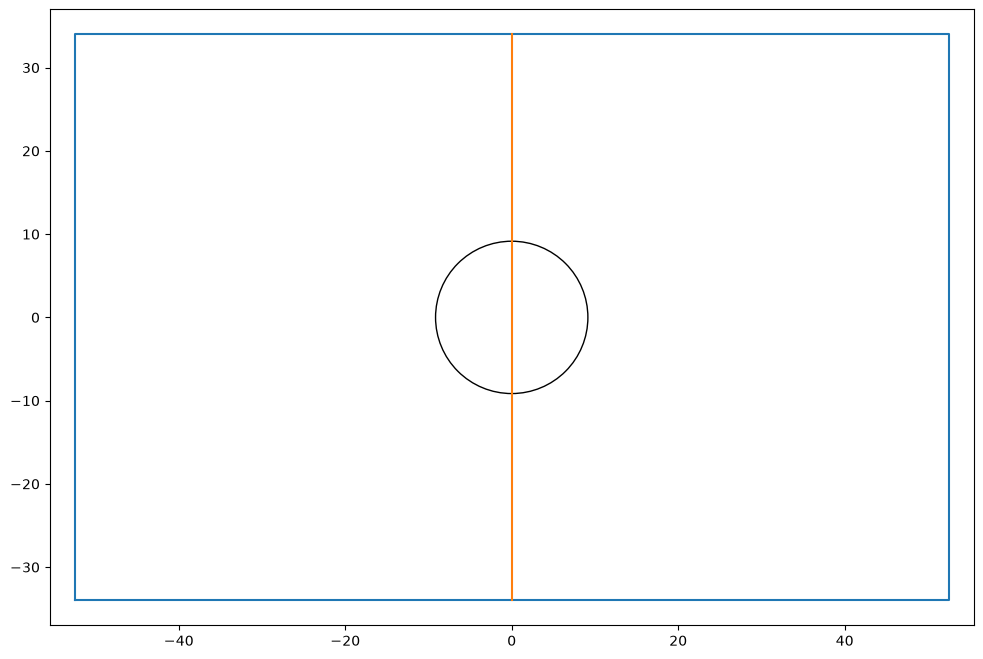

In [50]:
fig, ax = plt.subplots(figsize=(12, 8))

# Dimensioni campo
pitch_length = 105
pitch_width = 68

x_min = -pitch_length / 2
x_max = pitch_length / 2
y_min = -pitch_width / 2
y_max = pitch_width / 2

# Bordo del campo
ax.plot(
    [x_min, x_max, x_max, x_min, x_min],
    [y_min, y_min, y_max, y_max, y_min]
)

# Linea di metà campo
ax.plot([0, 0], [y_min, y_max])

# Cerchio di centrocampo
centre_circle = plt.Circle(
    (0, 0),
    9.15,
    fill=False
)

ax.add_patch(centre_circle)

ax.set_xlim(x_min - 3, x_max + 3)
ax.set_ylim(y_min - 3, y_max + 3)

ax.set_aspect("equal")

plt.show()

In [51]:
plot_players["team_name"].unique()

<StringArray>
['Sydney Football Club', 'Adelaide United Football Club']
Length: 2, dtype: str

In [52]:
home_name = match["home_team"]["name"]
away_name = match["away_team"]["name"]

home_players = plot_players[
    plot_players["team_name"] == home_name
]

away_players = plot_players[
    plot_players["team_name"] == away_name
]

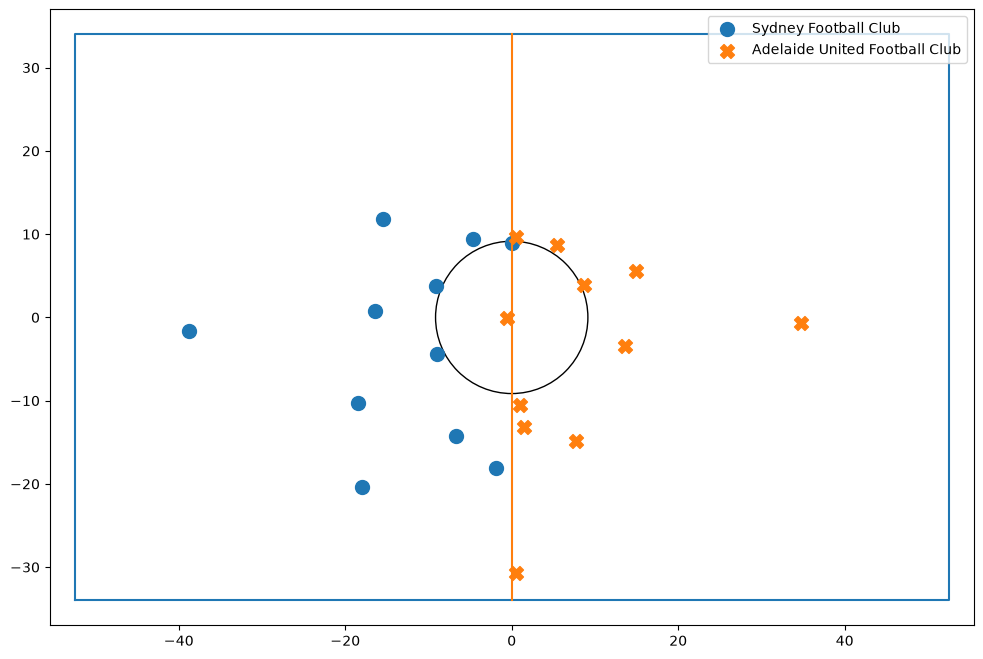

In [53]:
fig, ax = plt.subplots(figsize=(12, 8))

# Dimensioni del campo
pitch_length = 105
pitch_width = 68

x_min = -pitch_length / 2
x_max = pitch_length / 2
y_min = -pitch_width / 2
y_max = pitch_width / 2

# Disegniamo il bordo del campo
ax.plot(
    [x_min, x_max, x_max, x_min, x_min],
    [y_min, y_min, y_max, y_max, y_min]
)

# Disegniamo la linea di metà campo
ax.plot(
    [0, 0],
    [y_min, y_max]
)

# Disegniamo il cerchio centrale
centre_circle = plt.Circle(
    (0, 0),
    9.15,
    fill=False
)

ax.add_patch(centre_circle)

# QUI AGGIUNGIAMO I GIOCATORI DI CASA
ax.scatter(
    home_players["x"],
    home_players["y"],
    s=100,
    marker="o",
    label=home_name
)

# QUI AGGIUNGIAMO I GIOCATORI OSPITI
ax.scatter(
    away_players["x"],
    away_players["y"],
    s=100,
    marker="X",
    label=away_name
)

# Sistemiamo i limiti del grafico
ax.set_xlim(x_min - 3, x_max + 3)
ax.set_ylim(y_min - 3, y_max + 3)

# Mantiene corrette le proporzioni del campo
ax.set_aspect("equal")

# Mostra la legenda
ax.legend()

# Mostra il grafico
plt.show()

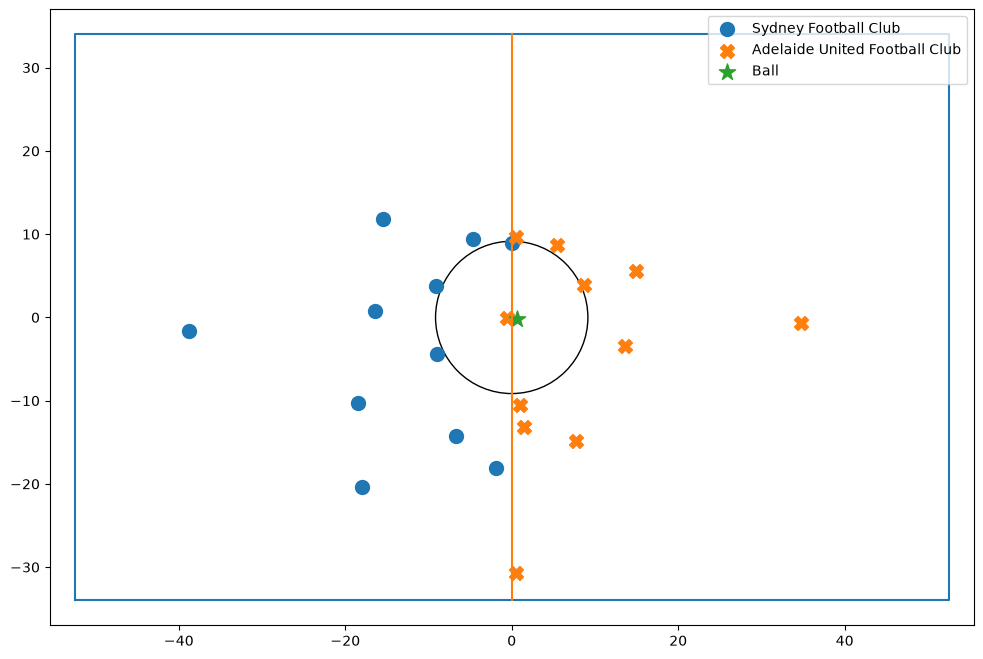

In [54]:
fig, ax = plt.subplots(figsize=(12, 8))

# Dimensioni del campo
pitch_length = 105
pitch_width = 68

x_min = -pitch_length / 2
x_max = pitch_length / 2
y_min = -pitch_width / 2
y_max = pitch_width / 2

# Disegniamo il bordo del campo
ax.plot(
    [x_min, x_max, x_max, x_min, x_min],
    [y_min, y_min, y_max, y_max, y_min]
)

# Disegniamo la linea di metà campo
ax.plot(
    [0, 0],
    [y_min, y_max]
)

# Disegniamo il cerchio centrale
centre_circle = plt.Circle(
    (0, 0),
    9.15,
    fill=False
)

ax.add_patch(centre_circle)

# Giocatori della squadra di casa
ax.scatter(
    home_players["x"],
    home_players["y"],
    s=100,
    marker="o",
    label=home_name
)

# Giocatori della squadra ospite
ax.scatter(
    away_players["x"],
    away_players["y"],
    s=100,
    marker="X",
    label=away_name
)

# Prendiamo i dati della palla dal frame
ball = plot_frame["ball_data"]

# Disegniamo la palla
ax.scatter(
    ball["x"],
    ball["y"],
    s=150,
    marker="*",
    label="Ball"
)

# Impostiamo i limiti del campo
ax.set_xlim(x_min - 3, x_max + 3)
ax.set_ylim(y_min - 3, y_max + 3)

# Mantiene corrette le proporzioni del campo
ax.set_aspect("equal")

# Aggiungiamo la legenda
ax.legend()

# Mostriamo il grafico
plt.show()

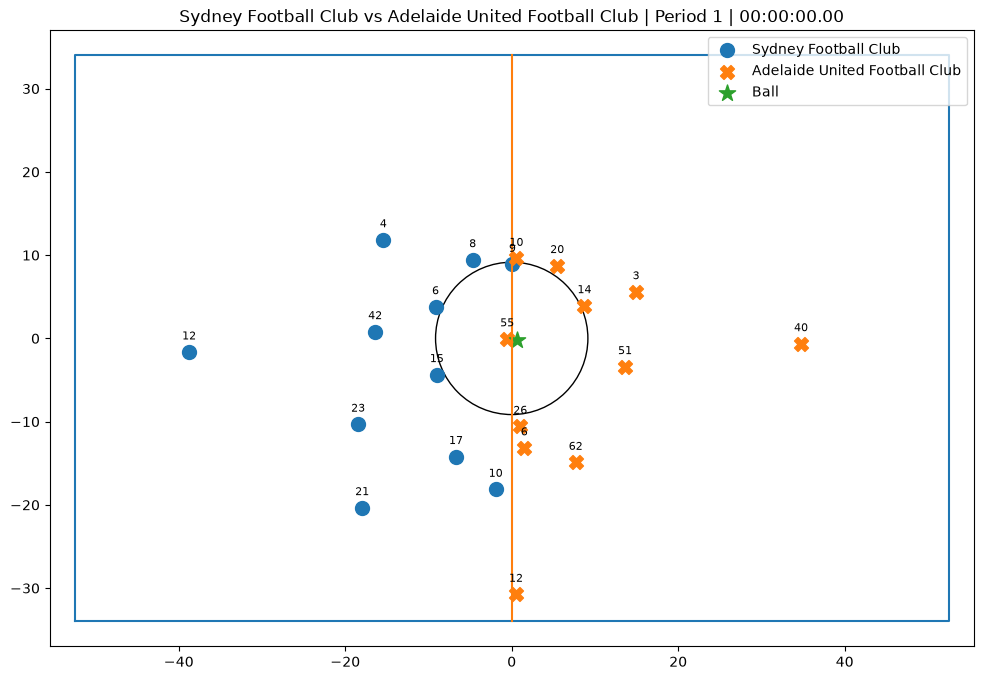

In [55]:
fig, ax = plt.subplots(figsize=(12, 8))

# Dimensioni del campo
pitch_length = 105
pitch_width = 68

x_min = -pitch_length / 2
x_max = pitch_length / 2
y_min = -pitch_width / 2
y_max = pitch_width / 2

# Bordo del campo
ax.plot(
    [x_min, x_max, x_max, x_min, x_min],
    [y_min, y_min, y_max, y_max, y_min]
)

# Linea di metà campo
ax.plot(
    [0, 0],
    [y_min, y_max]
)

# Cerchio centrale
centre_circle = plt.Circle(
    (0, 0),
    9.15,
    fill=False
)

ax.add_patch(centre_circle)

# Squadra di casa
ax.scatter(
    home_players["x"],
    home_players["y"],
    s=100,
    marker="o",
    label=home_name
)

# Squadra ospite
ax.scatter(
    away_players["x"],
    away_players["y"],
    s=100,
    marker="X",
    label=away_name
)

# Palla
ball = plot_frame["ball_data"]

ax.scatter(
    ball["x"],
    ball["y"],
    s=150,
    marker="*",
    label="Ball"
)

# Numeri di maglia
for _, player in plot_players.iterrows():
    ax.text(
        player["x"],
        player["y"] + 1.5,
        str(player["shirt_number"]),
        ha="center",
        fontsize=8
    )

# Limiti del campo
ax.set_xlim(x_min - 3, x_max + 3)
ax.set_ylim(y_min - 3, y_max + 3)

ax.set_aspect("equal")

# Titolo
ax.set_title(
    f"{home_name} vs {away_name} | "
    f"Period {plot_frame['period']} | "
    f"{plot_frame['timestamp']}"
)

# Legenda
ax.legend()

plt.show()

In [56]:
plot_frame["possession"]

{'player_id': None, 'group': None}

In [57]:
plot_frame["possession"]

{'player_id': None, 'group': None}

In [58]:
possession_player_id = plot_frame["possession"]["player_id"]

possession_player_id

In [59]:
possession_player_id = plot_frame["possession"]["player_id"]

possession_player_id

In [60]:
with open(TRACKING_FILE, "r", encoding="utf-8") as f:
    for line in f:
        frame = json.loads(line)

        ball = frame["ball_data"]
        possession = frame["possession"]
        players = frame["player_data"]

        if (
            len(players) == 22
            and frame["timestamp"] is not None
            and ball["x"] is not None
            and ball["y"] is not None
            and possession["player_id"] is not None
        ):
            possession_frame = frame
            break

In [61]:
print("Frame:", possession_frame["frame"])
print("Timestamp:", possession_frame["timestamp"])
print("Period:", possession_frame["period"])
print("Possession:", possession_frame["possession"])
print("Ball:", possession_frame["ball_data"])

Frame: 96
Timestamp: 00:00:08.60
Period: 1
Possession: {'player_id': 560893, 'group': 'away team'}
Ball: {'x': 1.25, 'y': -0.23, 'z': 0.28, 'is_detected': True}


In [62]:
possession_frame["possession"]

{'player_id': 560893, 'group': 'away team'}

In [63]:
possession_player_id = possession_frame["possession"]["player_id"]

possession_player_id

560893

In [64]:
[
    player
    for player in match["players"]
    if player["id"] == possession_player_id
]

[{'player_role': {'id': 21,
   'position_group': 'Midfield',
   'name': 'Left Defensive Midfield',
   'acronym': 'LDM'},
  'start_time': '00:00:00',
  'end_time': None,
  'number': 55,
  'yellow_card': 0,
  'red_card': 0,
  'injured': False,
  'goal': 0,
  'own_goal': 0,
  'playing_time': {'total': {'minutes_tip': 24.64,
    'minutes_otip': 28.97,
    'start_frame': 10,
    'end_frame': 57619,
    'minutes_played': 96.0,
    'minutes_played_regular_time': 96.0},
   'by_period': [{'name': 'period_1',
     'minutes_tip': 11.84,
     'minutes_otip': 17.53,
     'start_frame': 10,
     'end_frame': 28020,
     'minutes_played': 46.68},
    {'name': 'period_2',
     'minutes_tip': 12.79,
     'minutes_otip': 11.44,
     'start_frame': 28030,
     'end_frame': 57619,
     'minutes_played': 49.32}]},
  'team_player_id': 828191,
  'team_id': 866,
  'id': 560893,
  'first_name': 'Ethan',
  'last_name': 'Alagich',
  'short_name': 'E. Alagich',
  'birthday': '2003-12-18',
  'trackable_object': 56

In [65]:
possession_players_df = pd.DataFrame(
    possession_frame["player_data"]
)

possession_players = possession_players_df.merge(
    players_metadata,
    on="player_id",
    how="left"
)

possession_players["team_name"] = (
    possession_players["team_id"].map(team_lookup)
)

possession_players[
    [
        "player_name",
        "team_name",
        "shirt_number",
        "x",
        "y"
    ]
]

,player_name,team_name,shirt_number,x,y
0,H. Devenish-Meares,Sydney Football Club,12,-40.68,-1.00
1,R. Grant,Sydney Football Club,23,-18.64,-10.83
2,K. Shaw,Sydney Football Club,42,-16.14,0.65
3,Z. de Jesus,Sydney Football Club,21,-17.23,-20.91
4,J. Courtney-Perkins,Sydney Football Club,4,-15.42,13.44
5,Léo Sena,Sydney Football Club,15,-7.80,-4.41
6,C. Hollman,Sydney Football Club,6,-9.23,3.60
7,A. Cáceres,Sydney Football Club,17,-6.77,-13.28
8,J. Lolley,Sydney Football Club,10,-3.52,-18.86
9,A. Ouahim,Sydney Football Club,8,-5.82,9.48


In [66]:
possession_player_id = possession_frame["possession"]["player_id"]

In [67]:
ball_carrier = possession_players[
    possession_players["player_id"] == possession_player_id
]

ball_carrier

,x,y,player_id,is_detected,player_name,team_id,shirt_number,position,team_name
16,-0.26,-0.11,560893,True,E. Alagich,866,55,Left Defensive Midfield,Adelaide United Football Club


In [68]:
carrier = ball_carrier.iloc[0]

print("Ball carrier:", carrier["player_name"])
print("Team:", carrier["team_name"])
print("Shirt number:", carrier["shirt_number"])
print("Position:", carrier["position"])
print("Coordinates:", carrier["x"], carrier["y"])

Ball carrier: E. Alagich
Team: Adelaide United Football Club
Shirt number: 55
Position: Left Defensive Midfield
Coordinates: -0.26 -0.11


In [69]:
carrier_team_id = carrier["team_id"]

In [70]:
teammates = possession_players[
    (possession_players["team_id"] == carrier_team_id) &
    (possession_players["player_id"] != possession_player_id)
]

opponents = possession_players[
    possession_players["team_id"] != carrier_team_id
]

In [71]:
print("Teammates:", len(teammates))
print("Opponents:", len(opponents))

Teammates: 10
Opponents: 11


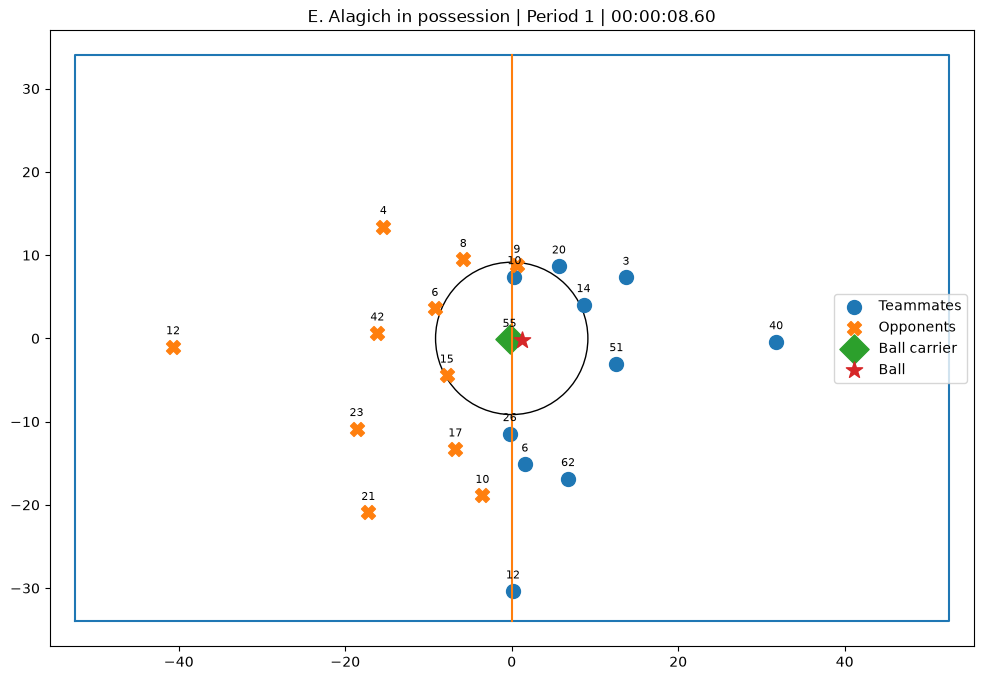

In [72]:
fig, ax = plt.subplots(figsize=(12, 8))

# Dimensioni campo
pitch_length = 105
pitch_width = 68

x_min = -pitch_length / 2
x_max = pitch_length / 2
y_min = -pitch_width / 2
y_max = pitch_width / 2

# Bordo campo
ax.plot(
    [x_min, x_max, x_max, x_min, x_min],
    [y_min, y_min, y_max, y_max, y_min]
)

# Linea metà campo
ax.plot(
    [0, 0],
    [y_min, y_max]
)

# Cerchio centrale
centre_circle = plt.Circle(
    (0, 0),
    9.15,
    fill=False
)

ax.add_patch(centre_circle)

# Compagni del portatore
ax.scatter(
    teammates["x"],
    teammates["y"],
    s=100,
    marker="o",
    label="Teammates"
)

# Avversari
ax.scatter(
    opponents["x"],
    opponents["y"],
    s=100,
    marker="X",
    label="Opponents"
)

# Portatore di palla
ax.scatter(
    carrier["x"],
    carrier["y"],
    s=220,
    marker="D",
    label="Ball carrier"
)

# Palla
ball = possession_frame["ball_data"]

ax.scatter(
    ball["x"],
    ball["y"],
    s=150,
    marker="*",
    label="Ball"
)

# Numeri di maglia
for _, player in possession_players.iterrows():
    ax.text(
        player["x"],
        player["y"] + 1.5,
        str(player["shirt_number"]),
        ha="center",
        fontsize=8
    )

# Limiti
ax.set_xlim(x_min - 3, x_max + 3)
ax.set_ylim(y_min - 3, y_max + 3)

ax.set_aspect("equal")

# Titolo
ax.set_title(
    f"{carrier['player_name']} in possession | "
    f"Period {possession_frame['period']} | "
    f"{possession_frame['timestamp']}"
)

ax.legend()

plt.show()

In [73]:
teammates = teammates.copy()

teammates["pass_distance"] = np.sqrt(
    (teammates["x"] - carrier["x"]) ** 2
    +
    (teammates["y"] - carrier["y"]) ** 2
)

In [74]:
teammates[
    [
        "player_name",
        "shirt_number",
        "x",
        "y",
        "pass_distance"
    ]
].sort_values("pass_distance")

,player_name,shirt_number,x,y,pass_distance
19,Z. Clough,10,0.32,7.42,7.552304
17,J. Barnett,14,8.63,4.06,9.819420
14,D. Pierias,20,5.67,8.70,10.619840
21,A. Goodwin,26,-0.24,-11.44,11.330018
13,P. Kikianis,51,12.57,-3.03,13.158089
18,S. Mauk,6,1.58,-15.10,15.102506
12,B. Vriends,3,13.73,7.34,15.850003
15,F. Talladira,62,6.77,-16.84,18.147005
20,J. Yull,12,0.15,-30.34,30.232780
11,E. Cox,40,31.77,-0.40,32.031313


In [75]:
candidate_passes = teammates.copy()

In [76]:
candidate_passes[
    [
        "player_name",
        "shirt_number",
        "pass_distance"
    ]
].sort_values("pass_distance")

,player_name,shirt_number,pass_distance
19,Z. Clough,10,7.552304
17,J. Barnett,14,9.819420
14,D. Pierias,20,10.619840
21,A. Goodwin,26,11.330018
13,P. Kikianis,51,13.158089
18,S. Mauk,6,15.102506
12,B. Vriends,3,15.850003
15,F. Talladira,62,18.147005
20,J. Yull,12,30.232780
11,E. Cox,40,32.031313


In [77]:
# Creiamo una copia della tabella dei compagni
candidate_passes = teammates.copy()

# Calcoliamo la distanza tra il portatore e ogni compagno
candidate_passes["pass_distance"] = np.sqrt(
    (candidate_passes["x"] - carrier["x"]) ** 2
    +
    (candidate_passes["y"] - carrier["y"]) ** 2
)

# Mostriamo solo le colonne che ci interessano,
# ordinate dal compagno più vicino al più lontano
candidate_passes[
    [
        "player_name",
        "shirt_number",
        "x",
        "y",
        "pass_distance"
    ]
].sort_values("pass_distance")

,player_name,shirt_number,x,y,pass_distance
19,Z. Clough,10,0.32,7.42,7.552304
17,J. Barnett,14,8.63,4.06,9.819420
14,D. Pierias,20,5.67,8.70,10.619840
21,A. Goodwin,26,-0.24,-11.44,11.330018
13,P. Kikianis,51,12.57,-3.03,13.158089
18,S. Mauk,6,1.58,-15.10,15.102506
12,B. Vriends,3,13.73,7.34,15.850003
15,F. Talladira,62,6.77,-16.84,18.147005
20,J. Yull,12,0.15,-30.34,30.232780
11,E. Cox,40,31.77,-0.40,32.031313


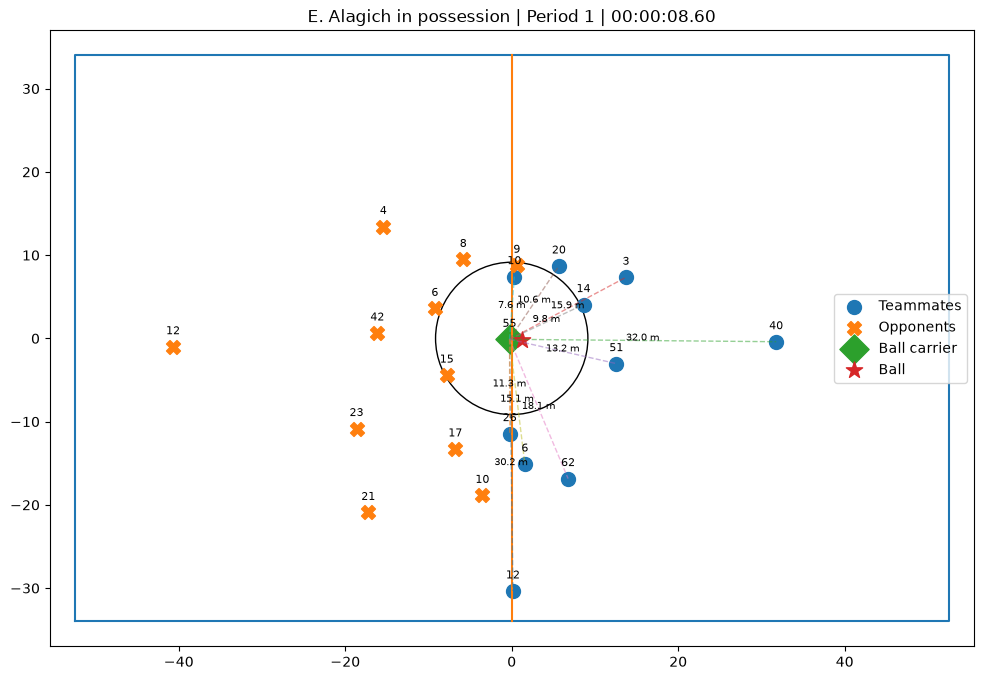

In [78]:
fig, ax = plt.subplots(figsize=(12, 8))

# Dimensioni del campo
pitch_length = 105
pitch_width = 68

x_min = -pitch_length / 2
x_max = pitch_length / 2
y_min = -pitch_width / 2
y_max = pitch_width / 2

# Bordo campo
ax.plot(
    [x_min, x_max, x_max, x_min, x_min],
    [y_min, y_min, y_max, y_max, y_min]
)

# Linea di metà campo
ax.plot(
    [0, 0],
    [y_min, y_max]
)

# Cerchio centrale
centre_circle = plt.Circle(
    (0, 0),
    9.15,
    fill=False
)

ax.add_patch(centre_circle)

# Compagni
ax.scatter(
    teammates["x"],
    teammates["y"],
    s=100,
    marker="o",
    label="Teammates"
)

# Avversari
ax.scatter(
    opponents["x"],
    opponents["y"],
    s=100,
    marker="X",
    label="Opponents"
)

# Portatore
ax.scatter(
    carrier["x"],
    carrier["y"],
    s=220,
    marker="D",
    label="Ball carrier"
)

# Palla
ball = possession_frame["ball_data"]

ax.scatter(
    ball["x"],
    ball["y"],
    s=150,
    marker="*",
    label="Ball"
)

# Disegniamo una linea verso ogni possibile ricevente
for _, teammate in candidate_passes.iterrows():

    ax.plot(
        [carrier["x"], teammate["x"]],
        [carrier["y"], teammate["y"]],
        linestyle="--",
        linewidth=1,
        alpha=0.5
    )

    # Punto medio della linea
    mid_x = (carrier["x"] + teammate["x"]) / 2
    mid_y = (carrier["y"] + teammate["y"]) / 2

    # Scriviamo la distanza del passaggio
    ax.text(
        mid_x,
        mid_y,
        f"{teammate['pass_distance']:.1f} m",
        fontsize=7,
        ha="center"
    )

# Numero di maglia sopra ogni giocatore
for _, player in possession_players.iterrows():

    ax.text(
        player["x"],
        player["y"] + 1.5,
        str(player["shirt_number"]),
        ha="center",
        fontsize=8
    )

# Limiti del campo
ax.set_xlim(x_min - 3, x_max + 3)
ax.set_ylim(y_min - 3, y_max + 3)

ax.set_aspect("equal")

# Titolo
ax.set_title(
    f"{carrier['player_name']} in possession | "
    f"Period {possession_frame['period']} | "
    f"{possession_frame['timestamp']}"
)

ax.legend()

plt.show()

In [79]:
# Cerchiamo il portiere della squadra del portatore
carrier_team_players = possession_players[
    possession_players["team_id"] == carrier_team_id
]

goalkeeper = carrier_team_players[
    carrier_team_players["position"].str.contains(
        "Goalkeeper",
        case=False,
        na=False
    )
]

# Controlliamo di aver trovato il portiere
print("Goalkeeper:")
display(goalkeeper[
    ["player_name", "position", "x", "y"]
])

# Posizione x del portiere
goalkeeper_x = goalkeeper.iloc[0]["x"]

# Se il portiere è a sinistra, la squadra attacca verso +x.
# Se il portiere è a destra, attacca verso -x.
if goalkeeper_x < 0:
    attack_direction = 1
else:
    attack_direction = -1

print("Attack direction:", attack_direction)

# Calcoliamo quanti metri ogni passaggio fa avanzare
# la palla verso la porta avversaria
candidate_passes["forward_progression"] = (
    attack_direction
    * (candidate_passes["x"] - carrier["x"])
)

# Visualizziamo i risultati
candidate_passes[
    [
        "player_name",
        "shirt_number",
        "pass_distance",
        "forward_progression"
    ]
].sort_values(
    "forward_progression",
    ascending=False
)

Goalkeeper:


,player_name,position,x,y
11,E. Cox,Goalkeeper,31.77,-0.4


Attack direction: -1


,player_name,shirt_number,pass_distance,forward_progression
21,A. Goodwin,26,11.330018,-0.02
20,J. Yull,12,30.232780,-0.41
19,Z. Clough,10,7.552304,-0.58
18,S. Mauk,6,15.102506,-1.84
14,D. Pierias,20,10.619840,-5.93
15,F. Talladira,62,18.147005,-7.03
17,J. Barnett,14,9.819420,-8.89
13,P. Kikianis,51,13.158089,-12.83
12,B. Vriends,3,15.850003,-13.99
11,E. Cox,40,32.031313,-32.03


In [80]:
# Funzione che calcola la distanza dal difensore più vicino
def nearest_defender_distance(receiver_x, receiver_y, opponents_df):

    distances = np.sqrt(
        (opponents_df["x"] - receiver_x) ** 2
        +
        (opponents_df["y"] - receiver_y) ** 2
    )

    return distances.min()


# Applichiamo la funzione a ogni possibile ricevente
candidate_passes["nearest_defender_distance"] = candidate_passes.apply(
    lambda row: nearest_defender_distance(
        row["x"],
        row["y"],
        opponents
    ),
    axis=1
)


# Visualizziamo il risultato
candidate_passes[
    [
        "player_name",
        "shirt_number",
        "pass_distance",
        "forward_progression",
        "nearest_defender_distance"
    ]
].sort_values(
    "nearest_defender_distance",
    ascending=False
)

,player_name,shirt_number,pass_distance,forward_progression,nearest_defender_distance
11,E. Cox,40,32.031313,-32.03,32.477355
13,P. Kikianis,51,13.158089,-12.83,16.808180
12,B. Vriends,3,15.850003,-13.99,13.189943
20,J. Yull,12,30.232780,-0.41,12.052357
15,F. Talladira,62,18.147005,-7.03,10.486396
17,J. Barnett,14,9.819420,-8.89,9.302312
21,A. Goodwin,26,11.330018,-0.02,6.784283
18,S. Mauk,6,15.102506,-1.84,6.336213
14,D. Pierias,20,10.619840,-5.93,5.050802
19,Z. Clough,10,7.552304,-0.58,1.402462


In [81]:
def nearest_defender_info(receiver_x, receiver_y, opponents_df):

    distances = np.sqrt(
        (opponents_df["x"] - receiver_x) ** 2
        +
        (opponents_df["y"] - receiver_y) ** 2
    )

    nearest_index = distances.idxmin()

    nearest_defender = opponents_df.loc[nearest_index]

    return pd.Series({
        "nearest_defender_name": nearest_defender["player_name"],
        "nearest_defender_distance": distances.loc[nearest_index]
    })

In [82]:
defender_info = candidate_passes.apply(
    lambda row: nearest_defender_info(
        row["x"],
        row["y"],
        opponents
    ),
    axis=1
)

candidate_passes[
    [
        "nearest_defender_name",
        "nearest_defender_distance"
    ]
] = defender_info

In [83]:
candidate_passes[
    [
        "player_name",
        "shirt_number",
        "pass_distance",
        "forward_progression",
        "nearest_defender_name",
        "nearest_defender_distance"
    ]
].sort_values(
    "nearest_defender_distance",
    ascending=False
)

,player_name,shirt_number,pass_distance,forward_progression,nearest_defender_name,nearest_defender_distance
11,E. Cox,40,32.031313,-32.03,P. Klimala,32.477355
13,P. Kikianis,51,13.158089,-12.83,P. Klimala,16.808180
12,B. Vriends,3,15.850003,-13.99,P. Klimala,13.189943
20,J. Yull,12,30.232780,-0.41,J. Lolley,12.052357
15,F. Talladira,62,18.147005,-7.03,J. Lolley,10.486396
17,J. Barnett,14,9.819420,-8.89,P. Klimala,9.302312
21,A. Goodwin,26,11.330018,-0.02,A. Cáceres,6.784283
18,S. Mauk,6,15.102506,-1.84,J. Lolley,6.336213
14,D. Pierias,20,10.619840,-5.93,P. Klimala,5.050802
19,Z. Clough,10,7.552304,-0.58,P. Klimala,1.402462


In [84]:
def passing_lane_features(
    carrier_x,
    carrier_y,
    receiver_x,
    receiver_y,
    opponents_df,
    lane_width=1.5
):

    # Coordinate del vettore portatore -> ricevente
    dx = receiver_x - carrier_x
    dy = receiver_y - carrier_y

    # Lunghezza al quadrato del passaggio
    segment_length_squared = dx**2 + dy**2

    # Caso limite: portatore e ricevente nella stessa posizione
    if segment_length_squared == 0:
        return pd.Series({
            "lane_blockers": 0,
            "nearest_lane_defender_distance": np.nan
        })

    lane_distances = []

    for _, opponent in opponents_df.iterrows():

        # Posizione dell'avversario rispetto al portatore
        px = opponent["x"] - carrier_x
        py = opponent["y"] - carrier_y

        # Proiezione dell'avversario sulla linea del passaggio
        t = (px * dx + py * dy) / segment_length_squared

        # Consideriamo solo avversari realmente compresi
        # tra portatore e ricevente
        if 0 <= t <= 1:

            projection_x = carrier_x + t * dx
            projection_y = carrier_y + t * dy

            # Distanza avversario-linea di passaggio
            distance_to_lane = np.sqrt(
                (opponent["x"] - projection_x) ** 2
                +
                (opponent["y"] - projection_y) ** 2
            )

            lane_distances.append(distance_to_lane)

    # Se nessun avversario è tra portatore e ricevente
    if len(lane_distances) == 0:
        return pd.Series({
            "lane_blockers": 0,
            "nearest_lane_defender_distance": np.nan
        })

    lane_distances = np.array(lane_distances)

    # Quanti avversari si trovano entro 1.5 m dalla linea
    blockers = np.sum(lane_distances <= lane_width)

    return pd.Series({
        "lane_blockers": blockers,
        "nearest_lane_defender_distance": lane_distances.min()
    })


# Calcoliamo queste feature per ogni possibile passaggio
lane_features = candidate_passes.apply(
    lambda row: passing_lane_features(
        carrier["x"],
        carrier["y"],
        row["x"],
        row["y"],
        opponents,
        lane_width=1.5
    ),
    axis=1
)

# Aggiungiamo le nuove colonne a candidate_passes
candidate_passes[
    [
        "lane_blockers",
        "nearest_lane_defender_distance"
    ]
] = lane_features


# Visualizziamo il risultato
candidate_passes[
    [
        "player_name",
        "shirt_number",
        "pass_distance",
        "forward_progression",
        "nearest_defender_distance",
        "lane_blockers",
        "nearest_lane_defender_distance"
    ]
].sort_values(
    ["lane_blockers", "nearest_lane_defender_distance"]
)

,player_name,shirt_number,pass_distance,forward_progression,nearest_defender_distance,lane_blockers,nearest_lane_defender_distance
20,J. Yull,12,30.232780,-0.41,12.052357,0.0,3.513977
14,D. Pierias,20,10.619840,-5.93,5.050802,0.0,4.239631
12,B. Vriends,3,15.850003,-13.99,13.189943,0.0,7.441954
21,A. Goodwin,26,11.330018,-0.02,6.784283,0.0,7.547579
17,J. Barnett,14,9.819420,-8.89,9.302312,0.0,7.683896
18,S. Mauk,6,15.102506,-1.84,6.336213,0.0,8.007717
15,F. Talladira,62,18.147005,-7.03,10.486396,0.0,8.617025
11,E. Cox,40,32.031313,-32.03,32.477355,0.0,8.907602
19,Z. Clough,10,7.552304,-0.58,1.402462,0.0,9.228428
13,P. Kikianis,51,13.158089,-12.83,16.808180,0.0,19.005929


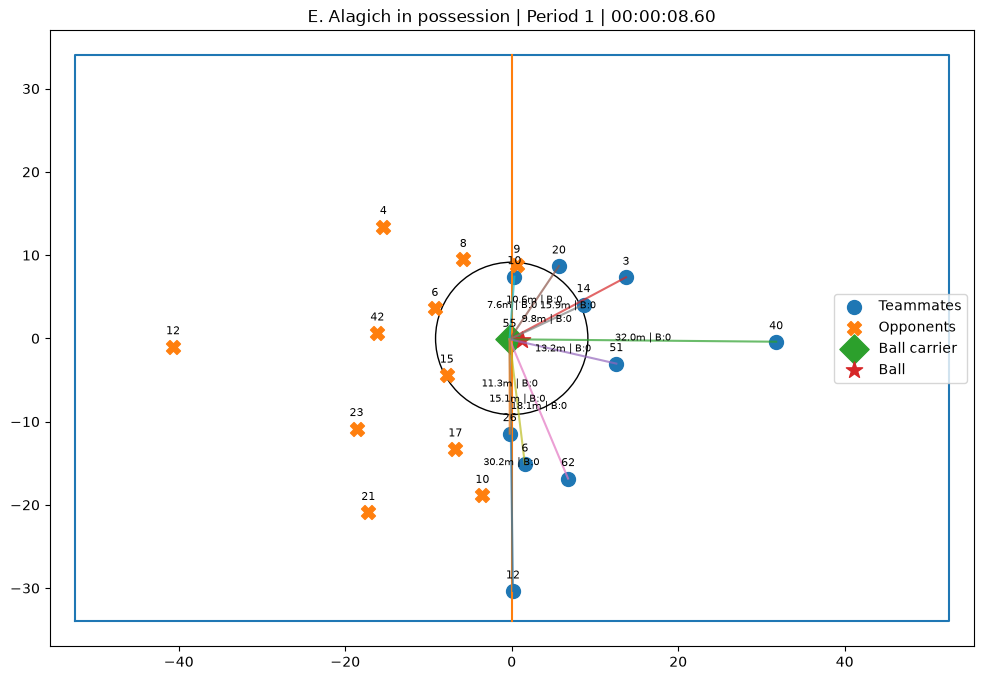

In [85]:
fig, ax = plt.subplots(figsize=(12, 8))

# Dimensioni del campo
pitch_length = 105
pitch_width = 68

x_min = -pitch_length / 2
x_max = pitch_length / 2
y_min = -pitch_width / 2
y_max = pitch_width / 2

# -----------------------
# CAMPO
# -----------------------

ax.plot(
    [x_min, x_max, x_max, x_min, x_min],
    [y_min, y_min, y_max, y_max, y_min]
)

ax.plot(
    [0, 0],
    [y_min, y_max]
)

centre_circle = plt.Circle(
    (0, 0),
    9.15,
    fill=False
)

ax.add_patch(centre_circle)

# -----------------------
# GIOCATORI
# -----------------------

# Compagni
ax.scatter(
    teammates["x"],
    teammates["y"],
    s=100,
    marker="o",
    label="Teammates"
)

# Avversari
ax.scatter(
    opponents["x"],
    opponents["y"],
    s=100,
    marker="X",
    label="Opponents"
)

# Portatore
ax.scatter(
    carrier["x"],
    carrier["y"],
    s=220,
    marker="D",
    label="Ball carrier"
)

# Palla
ball = possession_frame["ball_data"]

ax.scatter(
    ball["x"],
    ball["y"],
    s=150,
    marker="*",
    label="Ball"
)

# -----------------------
# CANDIDATE PASSES
# -----------------------

for _, candidate in candidate_passes.iterrows():

    # Se non ci sono blocker:
    # linea continua
    if candidate["lane_blockers"] == 0:
        line_style = "-"

    # Se ci sono blocker:
    # linea tratteggiata
    else:
        line_style = "--"

    ax.plot(
        [carrier["x"], candidate["x"]],
        [carrier["y"], candidate["y"]],
        linestyle=line_style,
        linewidth=1.5,
        alpha=0.7
    )

    # Punto medio del passaggio
    mid_x = (carrier["x"] + candidate["x"]) / 2
    mid_y = (carrier["y"] + candidate["y"]) / 2

    # Informazioni sulla linea
    label_text = (
        f"{candidate['pass_distance']:.1f}m | "
        f"B:{int(candidate['lane_blockers'])}"
    )

    ax.text(
        mid_x,
        mid_y,
        label_text,
        fontsize=7,
        ha="center"
    )

# -----------------------
# NUMERI DI MAGLIA
# -----------------------

for _, player in possession_players.iterrows():

    ax.text(
        player["x"],
        player["y"] + 1.5,
        str(player["shirt_number"]),
        ha="center",
        fontsize=8
    )

# -----------------------
# GRAFICO
# -----------------------

ax.set_xlim(x_min - 3, x_max + 3)
ax.set_ylim(y_min - 3, y_max + 3)

ax.set_aspect("equal")

ax.set_title(
    f"{carrier['player_name']} in possession | "
    f"Period {possession_frame['period']} | "
    f"{possession_frame['timestamp']}"
)

ax.legend()

plt.show()

In [86]:
events = pd.read_csv(EVENTS_FILE)

In [87]:
events.shape

(5171, 322)

In [88]:
events.head()

,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,...,possession_epv_against_start,possession_epv_against_end,pass_reception_epv_for,pass_reception_epv_against,possession_epv_total,pass_epv_total,possession_epv_delta_for,possession_epv_delta_against,pass_epv_delta_for,pass_epv_delta_against
0,8_0,0,1996435,95,95,NaN,00:08.5,00:08.5,0,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1_0,1,1996435,103,138,NaN,00:09.3,00:12.8,0,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8_1,2,1996435,118,137,NaN,00:10.8,00:12.7,0,10,...,NaN,NaN,0.0286,0.0177,NaN,NaN,NaN,NaN,NaN,NaN
3,7_0,3,1996435,118,137,NaN,00:10.8,00:12.7,0,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7_1,4,1996435,125,137,NaN,00:11.5,00:12.7,0,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
list(events.columns)

['event_id',
 'index',
 'match_id',
 'frame_start',
 'frame_end',
 'frame_physical_start',
 'time_start',
 'time_end',
 'minute_start',
 'second_start',
 'duration',
 'period',
 'attacking_side_id',
 'attacking_side',
 'event_type_id',
 'event_type',
 'event_subtype_id',
 'event_subtype',
 'player_id',
 'player_name',
 'player_position_id',
 'player_position',
 'player_in_possession_id',
 'player_in_possession_name',
 'player_in_possession_position_id',
 'player_in_possession_position',
 'team_id',
 'team_shortname',
 'x_start',
 'y_start',
 'channel_id_start',
 'channel_start',
 'third_id_start',
 'third_start',
 'penalty_area_start',
 'x_end',
 'y_end',
 'channel_id_end',
 'channel_end',
 'third_id_end',
 'third_end',
 'penalty_area_end',
 'associated_player_possession_event_id',
 'associated_player_possession_frame_start',
 'associated_player_possession_frame_end',
 'associated_player_possession_end_type_id',
 'associated_player_possession_end_type',
 'associated_off_ball_run_event_

In [90]:
for column in events.columns:
    print(column)

event_id
index
match_id
frame_start
frame_end
frame_physical_start
time_start
time_end
minute_start
second_start
duration
period
attacking_side_id
attacking_side
event_type_id
event_type
event_subtype_id
event_subtype
player_id
player_name
player_position_id
player_position
player_in_possession_id
player_in_possession_name
player_in_possession_position_id
player_in_possession_position
team_id
team_shortname
x_start
y_start
channel_id_start
channel_start
third_id_start
third_start
penalty_area_start
x_end
y_end
channel_id_end
channel_end
third_id_end
third_end
penalty_area_end
associated_player_possession_event_id
associated_player_possession_frame_start
associated_player_possession_frame_end
associated_player_possession_end_type_id
associated_player_possession_end_type
associated_off_ball_run_event_id
associated_off_ball_run_subtype_id
associated_off_ball_run_subtype
game_state_id
game_state
team_score
opponent_team_score
phase_index
player_possession_phase_index
first_player_possessio

In [91]:
# Dimensioni del dataset
print("Numero righe:", events.shape[0])
print("Numero colonne:", events.shape[1])

print("\n--- PRIME 5 RIGHE ---")
display(events.head())

print("\n--- NOMI DELLE COLONNE ---")
for i, column in enumerate(events.columns):
    print(i, "->", column)

print("\n--- TIPI DI DATO ---")
print(events.dtypes)

print("\n--- COLONNE CATEGORICHE / CON POCHI VALORI DIVERSI ---")

for column in events.columns:

    n_unique = events[column].nunique(dropna=True)

    if n_unique <= 15:
        print(f"\n{column} ({n_unique} valori):")
        print(events[column].dropna().unique())

Numero righe: 5171
Numero colonne: 322

--- PRIME 5 RIGHE ---


,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,...,possession_epv_against_start,possession_epv_against_end,pass_reception_epv_for,pass_reception_epv_against,possession_epv_total,pass_epv_total,possession_epv_delta_for,possession_epv_delta_against,pass_epv_delta_for,pass_epv_delta_against
0,8_0,0,1996435,95,95,NaN,00:08.5,00:08.5,0,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1_0,1,1996435,103,138,NaN,00:09.3,00:12.8,0,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8_1,2,1996435,118,137,NaN,00:10.8,00:12.7,0,10,...,NaN,NaN,0.0286,0.0177,NaN,NaN,NaN,NaN,NaN,NaN
3,7_0,3,1996435,118,137,NaN,00:10.8,00:12.7,0,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7_1,4,1996435,125,137,NaN,00:11.5,00:12.7,0,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- NOMI DELLE COLONNE ---
0 -> event_id
1 -> index
2 -> match_id
3 -> frame_start
4 -> frame_end
5 -> frame_physical_start
6 -> time_start
7 -> time_end
8 -> minute_start
9 -> second_start
10 -> duration
11 -> period
12 -> attacking_side_id
13 -> attacking_side
14 -> event_type_id
15 -> event_type
16 -> event_subtype_id
17 -> event_subtype
18 -> player_id
19 -> player_name
20 -> player_position_id
21 -> player_position
22 -> player_in_possession_id
23 -> player_in_possession_name
24 -> player_in_possession_position_id
25 -> player_in_possession_position
26 -> team_id
27 -> team_shortname
28 -> x_start
29 -> y_start
30 -> channel_id_start
31 -> channel_start
32 -> third_id_start
33 -> third_start
34 -> penalty_area_start
35 -> x_end
36 -> y_end
37 -> channel_id_end
38 -> channel_end
39 -> third_id_end
40 -> third_end
41 -> penalty_area_end
42 -> associated_player_possession_event_id
43 -> associated_player_possession_frame_start
44 -> associated_player_possession_frame_end
45 -> assoc

In [92]:
keywords = [
    "pass",
    "event",
    "player",
    "receiver",
    "recipient",
    "frame",
    "time",
    "timestamp",
    "possession",
    "outcome",
    "result",
    "success",
    "complete",
    "epv",
    "pressure"
]

interesting_columns = []

for column in events.columns:
    column_lower = column.lower()

    if any(keyword in column_lower for keyword in keywords):
        interesting_columns.append(column)

interesting_columns

['event_id',
 'frame_start',
 'frame_end',
 'frame_physical_start',
 'time_start',
 'time_end',
 'event_type_id',
 'event_type',
 'event_subtype_id',
 'event_subtype',
 'player_id',
 'player_name',
 'player_position_id',
 'player_position',
 'player_in_possession_id',
 'player_in_possession_name',
 'player_in_possession_position_id',
 'player_in_possession_position',
 'associated_player_possession_event_id',
 'associated_player_possession_frame_start',
 'associated_player_possession_frame_end',
 'associated_player_possession_end_type_id',
 'associated_player_possession_end_type',
 'associated_off_ball_run_event_id',
 'player_possession_phase_index',
 'first_player_possession_in_team_possession',
 'last_player_possession_in_team_possession',
 'n_player_possessions_in_phase',
 'team_possession_loss_in_phase',
 'team_in_possession_phase_type_id',
 'team_in_possession_phase_type',
 'team_out_of_possession_phase_type_id',
 'team_out_of_possession_phase_type',
 'current_team_in_possession_ne

In [93]:
events[interesting_columns].head(20)

,event_id,frame_start,frame_end,frame_physical_start,time_start,time_end,event_type_id,event_type,event_subtype_id,event_subtype,...,possession_epv_against_start,possession_epv_against_end,pass_reception_epv_for,pass_reception_epv_against,possession_epv_total,pass_epv_total,possession_epv_delta_for,possession_epv_delta_against,pass_epv_delta_for,pass_epv_delta_against
0,8_0,95,95,NaN,00:08.5,00:08.5,8,player_possession,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1_0,103,138,NaN,00:09.3,00:12.8,1,off_ball_run,8.0,run_ahead_of_the_ball,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8_1,118,137,NaN,00:10.8,00:12.7,8,player_possession,NaN,NaN,...,NaN,NaN,0.0286,0.0177,NaN,NaN,NaN,NaN,NaN,NaN
3,7_0,118,137,NaN,00:10.8,00:12.7,7,passing_option,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7_1,125,137,NaN,00:11.5,00:12.7,7,passing_option,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,7_2,129,137,NaN,00:11.9,00:12.7,7,passing_option,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,8_2,170,170,NaN,00:16.0,00:16.0,8,player_possession,NaN,NaN,...,0.0286,0.0286,0.0132,0.0368,0.000,-0.0127,0.0000,0.0000,-0.0045,0.0082
7,8_3,189,189,NaN,00:17.9,00:17.9,8,player_possession,NaN,NaN,...,0.0132,0.0132,0.0177,0.0223,0.000,-0.0282,0.0000,0.0000,-0.0191,0.0091
8,8_4,207,207,NaN,00:19.7,00:19.7,8,player_possession,NaN,NaN,...,0.0177,0.0177,0.0131,0.0370,0.000,-0.0285,0.0000,0.0000,-0.0092,0.0193
9,9_0,211,214,211.0,00:20.1,00:20.4,9,on_ball_engagement,15.0,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
for column in events.columns:

    if (
        "event" in column.lower()
        or "type" in column.lower()
        or "category" in column.lower()
    ):

        print("\nCOLUMN:", column)

        print(
            events[column]
            .dropna()
            .value_counts()
            .head(20)
        )


COLUMN: event_id
event_id
8_0    1
1_0    1
8_1    1
7_0    1
7_1    1
7_2    1
8_2    1
8_3    1
8_4    1
9_0    1
8_5    1
9_2    1
9_1    1
8_6    1
7_3    1
7_4    1
7_5    1
7_6    1
9_3    1
9_4    1
Name: count, dtype: int64

COLUMN: event_type_id
event_type_id
7    2626
9    1025
8    1005
1     515
Name: count, dtype: int64

COLUMN: event_type
event_type
passing_option        2626
on_ball_engagement    1025
player_possession     1005
off_ball_run           515
Name: count, dtype: int64

COLUMN: event_subtype_id
event_subtype_id
11.0    268
14.0    249
12.0    226
15.0    180
8.0     146
13.0    102
9.0     101
2.0      61
3.0      56
4.0      44
1.0      37
7.0      28
10.0     16
5.0      16
6.0      10
Name: count, dtype: int64

COLUMN: event_subtype
event_subtype
pressing                 268
recovery_press           249
pressure                 226
other                    180
run_ahead_of_the_ball    146
counter_press            102
support                  101
coming_sho

In [95]:
for column in events.columns:

    if events[column].dtype == "object":

        mask = events[column].astype(str).str.contains(
            "pass",
            case=False,
            na=False
        )

        if mask.any():
            print("\nFOUND 'pass' IN COLUMN:", column)
            print(events.loc[mask, column].value_counts().head(20))

In [96]:
for column in events.columns:
    if events[column].dtype == "object":

        values = events[column].dropna().astype(str)

        mask = values.isin([
            "player_possession",
            "on_ball_engagement",
            "off_ball_run",
            "passing_option"
        ])

        if mask.any():
            print("EVENT TYPE COLUMN:", column)
            print(events[column].value_counts())

In [97]:
search_terms = [
    "possession",
    "engagement",
    "off_ball",
    "passing",
    "option"
]

for column in events.columns:

    # Guardiamo solo colonne di testo
    if events[column].dtype == "object":

        values = (
            events[column]
            .dropna()
            .astype(str)
            .str.lower()
            .str.strip()
        )

        # Cerchiamo le parole anche se fanno parte di stringhe più lunghe
        mask = values.str.contains(
            "|".join(search_terms),
            regex=True,
            na=False
        )

        if mask.any():
            print("\n----------------------------")
            print("COLUMN:", column)
            print("----------------------------")

            print(
                events.loc[values.index[mask], column]
                .value_counts()
                .head(30)
            )

In [98]:
[
    column
    for column in events.columns
    if any(
        word in column.lower()
        for word in [
            "event",
            "type",
            "category",
            "possession"
        ]
    )
]

['event_id',
 'event_type_id',
 'event_type',
 'event_subtype_id',
 'event_subtype',
 'player_in_possession_id',
 'player_in_possession_name',
 'player_in_possession_position_id',
 'player_in_possession_position',
 'associated_player_possession_event_id',
 'associated_player_possession_frame_start',
 'associated_player_possession_frame_end',
 'associated_player_possession_end_type_id',
 'associated_player_possession_end_type',
 'associated_off_ball_run_event_id',
 'associated_off_ball_run_subtype_id',
 'associated_off_ball_run_subtype',
 'player_possession_phase_index',
 'first_player_possession_in_team_possession',
 'last_player_possession_in_team_possession',
 'n_player_possessions_in_phase',
 'team_possession_loss_in_phase',
 'team_in_possession_phase_type_id',
 'team_in_possession_phase_type',
 'team_out_of_possession_phase_type_id',
 'team_out_of_possession_phase_type',
 'current_team_in_possession_next_phase_type_id',
 'current_team_in_possession_next_phase_type',
 'current_team_

In [99]:
print("--- EVENT TYPES ---")
print(
    events["event_type"]
    .value_counts(dropna=False)
)

print("\n--- EVENT SUBTYPES ---")
print(
    events["event_subtype"]
    .value_counts(dropna=False)
    .head(40)
)

--- EVENT TYPES ---
event_type
passing_option        2626
on_ball_engagement    1025
player_possession     1005
off_ball_run           515
Name: count, dtype: int64

--- EVENT SUBTYPES ---
event_subtype
NaN                      3631
pressing                  268
recovery_press            249
pressure                  226
other                     180
run_ahead_of_the_ball     146
counter_press             102
support                   101
coming_short               61
cross_receiver             56
dropping_off               44
behind                     37
pulling_wide               28
underlap                   16
overlap                    16
pulling_half_space         10
Name: count, dtype: int64


In [100]:
event_view = events[
    [
        "event_id",
        "event_type",
        "event_subtype",
        "player_in_possession_id",
        "player_in_possession_name",
        "player_in_possession_position",
        "associated_player_possession_event_id",
        "associated_player_possession_frame_start",
        "associated_player_possession_frame_end",
        "associated_player_possession_end_type"
    ]
]

event_view.head(30)

,event_id,event_type,event_subtype,player_in_possession_id,player_in_possession_name,player_in_possession_position,associated_player_possession_event_id,associated_player_possession_frame_start,associated_player_possession_frame_end,associated_player_possession_end_type
0,8_0,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1_0,off_ball_run,run_ahead_of_the_ball,809070.0,E. Cox,GK,8_1,118.0,NaN,NaN
2,8_1,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7_0,passing_option,NaN,809070.0,E. Cox,GK,8_1,118.0,NaN,NaN
4,7_1,passing_option,NaN,809070.0,E. Cox,GK,8_1,118.0,NaN,NaN
5,7_2,passing_option,NaN,809070.0,E. Cox,GK,8_1,118.0,NaN,NaN
6,8_2,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8_3,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8_4,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9_0,on_ball_engagement,other,50959.0,S. Mauk,AM,8_5,214.0,214.0,pass


In [101]:
print("=== EVENT TYPES ===")
print(
    events["event_type"]
    .value_counts(dropna=False)
)

print("\n=== EVENT SUBTYPES ===")
print(
    events["event_subtype"]
    .value_counts(dropna=False)
    .head(50)
)

print("\n=== PLAYER POSSESSION END TYPES ===")
print(
    events["associated_player_possession_end_type"]
    .value_counts(dropna=False)
)

=== EVENT TYPES ===
event_type
passing_option        2626
on_ball_engagement    1025
player_possession     1005
off_ball_run           515
Name: count, dtype: int64

=== EVENT SUBTYPES ===
event_subtype
NaN                      3631
pressing                  268
recovery_press            249
pressure                  226
other                     180
run_ahead_of_the_ball     146
counter_press             102
support                   101
coming_short               61
cross_receiver             56
dropping_off               44
behind                     37
pulling_wide               28
underlap                   16
overlap                    16
pulling_half_space         10
Name: count, dtype: int64

=== PLAYER POSSESSION END TYPES ===
associated_player_possession_end_type
NaN                4146
pass                841
possession_loss     114
shot                 41
foul_suffered        17
clearance            10
unknown               2
Name: count, dtype: int64


In [102]:
possession_mask = (
    events["event_type"]
    .astype(str)
    .str.lower()
    .str.replace(" ", "_")
    .str.contains("player_possession", na=False)
)

player_possessions = events[possession_mask].copy()

print("Numero di player possessions:", len(player_possessions))

Numero di player possessions: 1005


In [103]:
possession_view = player_possessions[
    [
        "event_id",
        "event_type",
        "event_subtype",
        "player_in_possession_id",
        "player_in_possession_name",
        "player_in_possession_position",
        "associated_player_possession_frame_start",
        "associated_player_possession_frame_end",
        "associated_player_possession_end_type"
    ]
]

possession_view.head(20)

,event_id,event_type,event_subtype,player_in_possession_id,player_in_possession_name,player_in_possession_position,associated_player_possession_frame_start,associated_player_possession_frame_end,associated_player_possession_end_type
0,8_0,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8_1,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,8_2,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8_3,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8_4,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,8_5,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,8_6,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,8_7,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,8_8,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,8_9,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [104]:
# Per ogni colonna contiamo quanti valori NON NaN
# ci sono nelle sole righe player_possession

non_null_counts = (
    player_possessions
    .notna()
    .sum()
    .sort_values(ascending=False)
)

# Mostriamo solo le colonne che hanno almeno un valore
non_null_counts[non_null_counts > 0]

n_opponents_overtaken                            1005
n_opponents_ahead_start                          1005
n_opponents_ahead_end                            1005
n_passing_options_not_dangerous_difficult        1005
n_passing_options_not_dangerous_not_difficult    1005
                                                 ... 
furthest_line_break_type_id                       140
game_interruption_after_id                         89
game_interruption_after                            89
game_interruption_before                           77
game_interruption_before_id                        77
Length: 209, dtype: int64

In [105]:
possession_columns = [
    column
    for column in player_possessions.columns
    if any(
        word in column.lower()
        for word in [
            "player",
            "frame",
            "start",
            "end",
            "possession",
            "team",
            "group",
            "epv",
            "pressure",
            "passing"
        ]
    )
]

for column in possession_columns:
    count = player_possessions[column].notna().sum()

    if count > 0:
        print(f"{column}: {count}")

frame_start: 1005
frame_end: 1005
time_start: 1005
time_end: 1005
minute_start: 1005
second_start: 1005
player_id: 1005
player_name: 1005
player_position_id: 1005
player_position: 1005
team_id: 1005
team_shortname: 1005
x_start: 1002
y_start: 1002
channel_id_start: 1005
channel_start: 1005
third_id_start: 1005
third_start: 1005
penalty_area_start: 1005
x_end: 1003
y_end: 1003
channel_id_end: 1005
channel_end: 1005
third_id_end: 1005
third_end: 1005
penalty_area_end: 1005
team_score: 1005
opponent_team_score: 1005
player_possession_phase_index: 1005
first_player_possession_in_team_possession: 1005
last_player_possession_in_team_possession: 1005
n_player_possessions_in_phase: 1005
team_possession_loss_in_phase: 1005
team_in_possession_phase_type_id: 1005
team_in_possession_phase_type: 1005
team_out_of_possession_phase_type_id: 1005
team_out_of_possession_phase_type: 1005
current_team_in_possession_next_phase_type_id: 975
current_team_in_possession_next_phase_type: 975
current_team_out_of

In [106]:
first_possession = player_possessions.iloc[0]

filled_fields = first_possession[
    first_possession.notna()
]

filled_fields

event_id                                  8_0
index                                       0
match_id                              1996435
frame_start                                95
frame_end                                  95
                                       ...   
n_opponents_overtaken                     0.0
is_player_possession_start_matched       True
is_player_possession_end_matched         True
is_pass_reception_matched               False
fully_extrapolated                      False
Name: 0, Length: 134, dtype: object

In [107]:
useful_possession_columns = [
    "event_id",
    "event_type",

    "possession_epv_for_start",
    "possession_epv_for_end",
    "possession_epv_against_start",
    "possession_epv_against_end",
    "possession_epv_delta_for",
    "possession_epv_delta_against",
    "possession_epv_total",

    "pass_reception_epv_for",
    "pass_reception_epv_against",
    "pass_epv_delta_for",
    "pass_epv_delta_against",
    "pass_epv_total",

    "overall_pressure_start",
    "overall_pressure_end",

    "reception_difficulty_start",
    "space_constraint_start",

    "time_to_impact_start",
    "time_to_impact_end",

    "passing_option_ease_start",
    "passing_option_ease_end"
]

# Teniamo solo le colonne che esistono davvero nel tuo CSV
available_columns = [
    column
    for column in useful_possession_columns
    if column in player_possessions.columns
]

footballiq_possessions = player_possessions[
    available_columns
].copy()

footballiq_possessions.head(20)

,event_id,event_type,possession_epv_for_start,possession_epv_for_end,possession_epv_against_start,possession_epv_against_end,possession_epv_delta_for,possession_epv_delta_against,possession_epv_total,pass_reception_epv_for,...,pass_epv_delta_against,pass_epv_total,overall_pressure_start,overall_pressure_end,reception_difficulty_start,space_constraint_start,time_to_impact_start,time_to_impact_end,passing_option_ease_start,passing_option_ease_end
0,8_0,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8_1,player_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,8_2,player_possession,0.0177,0.0177,0.0286,0.0286,0.0000,0.0000,0.0000,0.0132,...,0.0082,-0.0127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8_3,player_possession,0.0368,0.0368,0.0132,0.0132,0.0000,0.0000,0.0000,0.0177,...,0.0091,-0.0282,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8_4,player_possession,0.0223,0.0223,0.0177,0.0177,0.0000,0.0000,0.0000,0.0131,...,0.0193,-0.0285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,8_5,player_possession,0.0370,0.0370,0.0131,0.0131,0.0000,0.0000,0.0000,0.0319,...,0.0026,-0.0077,high_pressure,high_pressure,hard,hard,medium,medium,hard,hard
13,8_6,player_possession,0.0384,0.0318,0.0142,0.0157,-0.0066,0.0014,-0.0080,0.0225,...,0.0052,-0.0145,very_high_pressure,very_high_pressure,hard,very_hard,very_hard,hard,very_hard,very_hard
20,8_7,player_possession,0.0208,0.0208,0.0225,0.0225,0.0000,0.0000,0.0000,0.0227,...,-0.0055,0.0074,high_pressure,high_pressure,hard,medium,very_hard,very_hard,medium,medium
23,8_8,player_possession,0.0227,0.0226,0.0170,0.0170,-0.0001,0.0000,-0.0001,NaN,...,NaN,NaN,low_pressure,medium_pressure,hard,easy,very_easy,medium,medium,hard
25,8_9,player_possession,0.0174,0.0200,0.0221,0.0188,0.0026,-0.0032,0.0058,0.0185,...,0.0015,-0.0029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [108]:
sample_possession = footballiq_possessions.iloc[0]

sample_possession

event_id                                      8_0
event_type                      player_possession
possession_epv_for_start                      NaN
possession_epv_for_end                        NaN
possession_epv_against_start                  NaN
possession_epv_against_end                    NaN
possession_epv_delta_for                      NaN
possession_epv_delta_against                  NaN
possession_epv_total                          NaN
pass_reception_epv_for                        NaN
pass_reception_epv_against                    NaN
pass_epv_delta_for                            NaN
pass_epv_delta_against                        NaN
pass_epv_total                                NaN
overall_pressure_start                        NaN
overall_pressure_end                          NaN
reception_difficulty_start                    NaN
space_constraint_start                        NaN
time_to_impact_start                          NaN
time_to_impact_end                            NaN


In [109]:
# Contiamo quante informazioni NON mancanti
# possiede ogni player_possession

footballiq_possessions["non_null_features"] = (
    footballiq_possessions
    .notna()
    .sum(axis=1)
)

# Ordiniamo dalla riga più completa alla meno completa
most_complete_possessions = (
    footballiq_possessions
    .sort_values(
        "non_null_features",
        ascending=False
    )
)

most_complete_possessions.head(10)

,event_id,event_type,possession_epv_for_start,possession_epv_for_end,possession_epv_against_start,possession_epv_against_end,possession_epv_delta_for,possession_epv_delta_against,possession_epv_total,pass_reception_epv_for,...,pass_epv_total,overall_pressure_start,overall_pressure_end,reception_difficulty_start,space_constraint_start,time_to_impact_start,time_to_impact_end,passing_option_ease_start,passing_option_ease_end,non_null_features
5151,8_1001,player_possession,0.0327,0.0347,0.0140,0.0142,0.0020,0.0002,0.0018,0.0382,...,0.0037,no_pressure,low_pressure,medium,easy,very_easy,easy,easy,easy,22
5145,8_1000,player_possession,0.0257,0.0260,0.0154,0.0153,0.0002,-0.0001,0.0003,0.0327,...,0.0080,no_pressure,no_pressure,easy,very_easy,easy,very_easy,very_easy,easy,22
5142,8_999,player_possession,0.0234,0.0261,0.0165,0.0153,0.0027,-0.0012,0.0039,0.0257,...,-0.0005,no_pressure,no_pressure,very_easy,very_easy,very_easy,very_easy,very_easy,very_easy,22
5140,8_998,player_possession,0.0263,0.0263,0.0150,0.0150,0.0000,0.0000,0.0000,0.0234,...,-0.0043,low_pressure,low_pressure,very_easy,easy,medium,medium,easy,easy,22
5037,8_979,player_possession,0.0653,0.0672,0.0138,0.0137,0.0019,-0.0000,0.0019,0.0444,...,-0.0230,high_pressure,high_pressure,medium,medium,very_hard,very_hard,hard,hard,22
5027,8_978,player_possession,0.0179,0.0251,0.0286,0.0156,0.0072,-0.0130,0.0203,0.0653,...,0.0420,high_pressure,low_pressure,easy,medium,very_hard,easy,medium,hard,22
5001,8_975,player_possession,0.0240,0.0277,0.0155,0.0165,0.0037,0.0009,0.0028,0.0606,...,0.0365,high_pressure,very_high_pressure,hard,medium,medium,very_hard,hard,hard,22
4994,8_974,player_possession,0.0214,0.0213,0.0177,0.0178,-0.0001,0.0001,-0.0001,0.0198,...,-0.0030,high_pressure,high_pressure,hard,hard,medium,very_hard,hard,medium,22
4989,8_973,player_possession,0.0185,0.0207,0.0205,0.0184,0.0022,-0.0021,0.0042,0.0214,...,0.0014,high_pressure,high_pressure,very_hard,medium,easy,hard,hard,hard,22
4982,8_972,player_possession,0.0165,0.0165,0.0235,0.0235,0.0000,0.0000,0.0000,0.0185,...,0.0050,very_high_pressure,very_high_pressure,medium,very_hard,very_hard,very_hard,hard,hard,22


In [110]:
sample_possession = most_complete_possessions.iloc[0]

sample_possession

event_id                                   8_1001
event_type                      player_possession
possession_epv_for_start                   0.0327
possession_epv_for_end                     0.0347
possession_epv_against_start                0.014
possession_epv_against_end                 0.0142
possession_epv_delta_for                    0.002
possession_epv_delta_against               0.0002
possession_epv_total                       0.0018
pass_reception_epv_for                     0.0382
pass_reception_epv_against                  0.014
pass_epv_delta_for                         0.0036
pass_epv_delta_against                    -0.0002
pass_epv_total                             0.0037
overall_pressure_start                no_pressure
overall_pressure_end                 low_pressure
reception_difficulty_start                 medium
space_constraint_start                       easy
time_to_impact_start                    very_easy
time_to_impact_end                           easy


In [111]:
sample_possession[
    sample_possession.notna()
]

event_id                                   8_1001
event_type                      player_possession
possession_epv_for_start                   0.0327
possession_epv_for_end                     0.0347
possession_epv_against_start                0.014
possession_epv_against_end                 0.0142
possession_epv_delta_for                    0.002
possession_epv_delta_against               0.0002
possession_epv_total                       0.0018
pass_reception_epv_for                     0.0382
pass_reception_epv_against                  0.014
pass_epv_delta_for                         0.0036
pass_epv_delta_against                    -0.0002
pass_epv_total                             0.0037
overall_pressure_start                no_pressure
overall_pressure_end                 low_pressure
reception_difficulty_start                 medium
space_constraint_start                       easy
time_to_impact_start                    very_easy
time_to_impact_end                           easy


In [112]:
sample_event_id = sample_possession["event_id"]

sample_event_id

'8_1001'

In [113]:
full_sample_possession = player_possessions[
    player_possessions["event_id"] == sample_event_id
].iloc[0]

In [114]:
full_sample_possession[
    full_sample_possession.notna()
]

event_id                         8_1001
index                              5151
match_id                        1996435
frame_start                       57237
frame_end                         57261
                                 ...   
pass_epv_total                   0.0037
possession_epv_delta_for          0.002
possession_epv_delta_against     0.0002
pass_epv_delta_for               0.0036
pass_epv_delta_against          -0.0002
Name: 5151, Length: 205, dtype: object

In [115]:
keywords = [
    "frame",
    "player",
    "team",
    "group",
    "start",
    "end",
    "type"
]

for column, value in full_sample_possession.items():

    if pd.notna(value):

        if any(
            keyword in column.lower()
            for keyword in keywords
        ):
            print(f"{column}: {value}")

frame_start: 57237
frame_end: 57261
time_start: 93:40.7
time_end: 93:43.1
minute_start: 93
second_start: 40
event_type_id: 8
event_type: player_possession
player_id: 973078
player_name: F. Talladira
player_position_id: 2
player_position: LB
team_id: 866
team_shortname: Adelaide United
x_start: 1.48
y_start: 32.86
channel_id_start: 1
channel_start: wide_left
third_id_start: 2
third_start: middle_third
penalty_area_start: False
x_end: 10.92
y_end: 31.29
channel_id_end: 1
channel_end: wide_left
third_id_end: 2
third_end: middle_third
penalty_area_end: False
team_score: 1
opponent_team_score: 4
player_possession_phase_index: 5.0
first_player_possession_in_team_possession: False
last_player_possession_in_team_possession: False
n_player_possessions_in_phase: 6.0
team_possession_loss_in_phase: False
team_in_possession_phase_type_id: 1
team_in_possession_phase_type: create
team_out_of_possession_phase_type_id: 9
team_out_of_possession_phase_type: medium_block
current_team_in_possession_next_ph

In [116]:
for column, value in full_sample_possession.items():

    if "frame" in column.lower() and pd.notna(value):
        print(f"{column}: {value}")

frame_start: 57237
frame_end: 57261


In [117]:
for column, value in full_sample_possession.items():

    if (
        "player" in column.lower()
        and pd.notna(value)
    ):
        print(f"{column}: {value}")

player_id: 973078
player_name: F. Talladira
player_position_id: 2
player_position: LB
player_possession_phase_index: 5.0
first_player_possession_in_team_possession: False
last_player_possession_in_team_possession: False
n_player_possessions_in_phase: 6.0
player_targeted_id: 50971.0
player_targeted_name: Y. Dukuly
player_targeted_position_id: 16.0
player_targeted_position: LW
player_targeted_x_pass: 20.76
player_targeted_y_pass: 33.07
player_targeted_channel_pass_id: 1.0
player_targeted_channel_pass: wide_left
player_targeted_third_pass_id: 3.0
player_targeted_third_pass: attacking_third
player_targeted_penalty_area_pass: False
player_targeted_x_reception: 23.11
player_targeted_y_reception: 32.34
player_targeted_channel_reception_id: 1.0
player_targeted_channel_reception: wide_left
player_targeted_third_reception_id: 3.0
player_targeted_third_reception: attacking_third
player_targeted_penalty_area_reception: False
player_targeted_xpass_completion: 0.9822
player_targeted_difficult_pass_t

In [118]:
frame_fields = {
    column: value
    for column, value in full_sample_possession.items()
    if "frame" in column.lower() and pd.notna(value)
}

pd.Series(frame_fields)

frame_start    57237
frame_end      57261
dtype: int64

In [119]:
start_frame_fields = {
    column: value
    for column, value in frame_fields.items()
    if "start" in column.lower()
}

end_frame_fields = {
    column: value
    for column, value in frame_fields.items()
    if "end" in column.lower()
}

print("START FRAME FIELDS")
for key, value in start_frame_fields.items():
    print(key, "=", value)

print("\nEND FRAME FIELDS")
for key, value in end_frame_fields.items():
    print(key, "=", value)

START FRAME FIELDS
frame_start = 57237

END FRAME FIELDS
frame_end = 57261


In [120]:
decision_frame_number = int(
    full_sample_possession["frame_end"]
) - 1

decision_frame_number

57260

In [121]:
# Cerchiamo tutti i campi valorizzati che contengono "frame" e "end"
end_frame_candidates = {
    column: value
    for column, value in full_sample_possession.items()
    if (
        "frame" in column.lower()
        and "end" in column.lower()
        and pd.notna(value)
    )
}

end_frame_candidates

{'frame_end': np.int64(57261)}

In [122]:
end_frame_column = list(end_frame_candidates.keys())[0]
end_frame_number = int(end_frame_candidates[end_frame_column])

print("Column:", end_frame_column)
print("End frame:", end_frame_number)

Column: frame_end
End frame: 57261


In [123]:
decision_frame_number = end_frame_number - 1

print("Decision frame:", decision_frame_number)

Decision frame: 57260


In [124]:
decision_frame = None

with open(TRACKING_FILE, "r", encoding="utf-8") as f:
    for line in f:
        frame = json.loads(line)

        if frame["frame"] == decision_frame_number:
            decision_frame = frame
            break

In [125]:
decision_frame is not None

True

In [126]:
print("Frame:", decision_frame["frame"])
print("Timestamp:", decision_frame["timestamp"])
print("Period:", decision_frame["period"])
print("Possession:", decision_frame["possession"])
print("Players:", len(decision_frame["player_data"]))
print("Ball:", decision_frame["ball_data"])

Frame: 57260
Timestamp: 01:33:43.00
Period: 2
Possession: {'player_id': 973078, 'group': 'away team'}
Players: 22
Ball: {'x': 11.61, 'y': 30.79, 'z': 0.15, 'is_detected': True}


In [127]:
# Trasformiamo i giocatori del decision frame in una tabella
decision_players_df = pd.DataFrame(
    decision_frame["player_data"]
)

# Aggiungiamo nome, squadra, numero e ruolo
decision_players = decision_players_df.merge(
    players_metadata,
    on="player_id",
    how="left"
)

# Aggiungiamo il nome della squadra
decision_players["team_name"] = (
    decision_players["team_id"].map(team_lookup)
)

decision_players[
    [
        "player_id",
        "player_name",
        "team_name",
        "shirt_number",
        "position",
        "x",
        "y"
    ]
]

,player_id,player_name,team_name,shirt_number,position,x,y
0,809070,E. Cox,Adelaide United Football Club,40,Goalkeeper,-34.31,2.24
1,26766,B. Vriends,Adelaide United Football Club,3,Right Center Back,-7.99,-13.08
2,809759,P. Kikianis,Adelaide United Football Club,51,Left Center Back,-10.80,8.13
3,51005,D. Pierias,Adelaide United Football Club,20,Right Back,17.15,-25.91
4,973078,F. Talladira,Adelaide United Football Club,62,Left Back,10.55,31.42
5,560893,E. Alagich,Adelaide United Football Club,55,Left Defensive Midfield,0.49,11.24
6,560895,Isaias,Adelaide United Football Club,8,Right Defensive Midfield,7.91,5.70
7,962802,R. White,Adelaide United Football Club,44,Attacking Midfield,18.76,16.67
8,808608,A. Ayoubi,Adelaide United Football Club,42,Right Winger,18.64,-14.17
9,50971,Y. Dukuly,Adelaide United Football Club,19,Left Winger,20.32,33.15


In [128]:
decision_possession_player_id = (
    decision_frame["possession"]["player_id"]
)

print(
    "Possession player ID:",
    decision_possession_player_id
)

Possession player ID: 973078


In [129]:
decision_carrier_df = decision_players[
    decision_players["player_id"]
    == decision_possession_player_id
]

decision_carrier_df

,x,y,player_id,is_detected,player_name,team_id,shirt_number,position,team_name
4,10.55,31.42,973078,True,F. Talladira,866,62,Left Back,Adelaide United Football Club


In [130]:
decision_carrier = decision_carrier_df.iloc[0]

print("Ball carrier:", decision_carrier["player_name"])
print("Team:", decision_carrier["team_name"])
print("Number:", decision_carrier["shirt_number"])
print("Position:", decision_carrier["position"])
print(
    "Coordinates:",
    decision_carrier["x"],
    decision_carrier["y"]
)

Ball carrier: F. Talladira
Team: Adelaide United Football Club
Number: 62
Position: Left Back
Coordinates: 10.55 31.42


In [131]:
decision_team_id = decision_carrier["team_id"]

decision_teammates = decision_players[
    (decision_players["team_id"] == decision_team_id)
    &
    (
        decision_players["player_id"]
        != decision_possession_player_id
    )
].copy()

decision_opponents = decision_players[
    decision_players["team_id"] != decision_team_id
].copy()

print(
    "Teammates:",
    len(decision_teammates)
)

print(
    "Opponents:",
    len(decision_opponents)
)

Teammates: 10
Opponents: 11


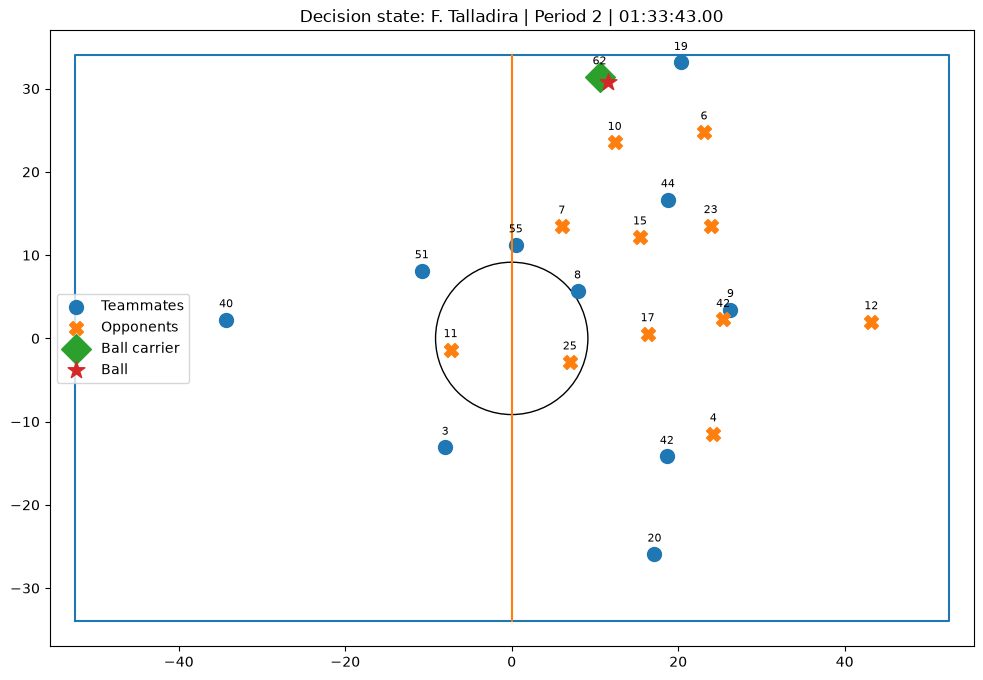

In [132]:
fig, ax = plt.subplots(figsize=(12, 8))

# Dimensioni campo
pitch_length = 105
pitch_width = 68

x_min = -pitch_length / 2
x_max = pitch_length / 2
y_min = -pitch_width / 2
y_max = pitch_width / 2


# -------------------------
# CAMPO
# -------------------------

ax.plot(
    [x_min, x_max, x_max, x_min, x_min],
    [y_min, y_min, y_max, y_max, y_min]
)

ax.plot(
    [0, 0],
    [y_min, y_max]
)

centre_circle = plt.Circle(
    (0, 0),
    9.15,
    fill=False
)

ax.add_patch(centre_circle)


# -------------------------
# GIOCATORI
# -------------------------

ax.scatter(
    decision_teammates["x"],
    decision_teammates["y"],
    s=100,
    marker="o",
    label="Teammates"
)

ax.scatter(
    decision_opponents["x"],
    decision_opponents["y"],
    s=100,
    marker="X",
    label="Opponents"
)

# Portatore evidenziato
ax.scatter(
    decision_carrier["x"],
    decision_carrier["y"],
    s=230,
    marker="D",
    label="Ball carrier"
)


# -------------------------
# PALLA
# -------------------------

decision_ball = decision_frame["ball_data"]

ax.scatter(
    decision_ball["x"],
    decision_ball["y"],
    s=160,
    marker="*",
    label="Ball"
)


# -------------------------
# NUMERI DI MAGLIA
# -------------------------

for _, player in decision_players.iterrows():

    ax.text(
        player["x"],
        player["y"] + 1.5,
        str(player["shirt_number"]),
        ha="center",
        fontsize=8
    )


# -------------------------
# GRAFICO
# -------------------------

ax.set_xlim(
    x_min - 3,
    x_max + 3
)

ax.set_ylim(
    y_min - 3,
    y_max + 3
)

ax.set_aspect("equal")

ax.set_title(
    f"Decision state: "
    f"{decision_carrier['player_name']} | "
    f"Period {decision_frame['period']} | "
    f"{decision_frame['timestamp']}"
)

ax.legend()

plt.show()

In [133]:
# ============================================================
# 1. CREIAMO I CANDIDATE PASSES
# ============================================================

decision_candidates = decision_teammates.copy()


# ============================================================
# 2. DISTANZA DEL PASSAGGIO
# ============================================================

decision_candidates["pass_distance"] = np.sqrt(
    (decision_candidates["x"] - decision_carrier["x"]) ** 2
    +
    (decision_candidates["y"] - decision_carrier["y"]) ** 2
)


# ============================================================
# 3. DIREZIONE DI ATTACCO
# ============================================================

# Cerchiamo il portiere della squadra del portatore
decision_team_players = decision_players[
    decision_players["team_id"] == decision_team_id
]

decision_goalkeeper = decision_team_players[
    decision_team_players["position"].str.contains(
        "Goalkeeper",
        case=False,
        na=False
    )
]

goalkeeper_x = decision_goalkeeper.iloc[0]["x"]

# Portiere a sinistra -> attacco verso +x
# Portiere a destra -> attacco verso -x
if goalkeeper_x < 0:
    decision_attack_direction = 1
else:
    decision_attack_direction = -1


# ============================================================
# 4. FORWARD PROGRESSION
# ============================================================

decision_candidates["forward_progression"] = (
    decision_attack_direction
    *
    (
        decision_candidates["x"]
        - decision_carrier["x"]
    )
)


# ============================================================
# 5. DIFENSORE PIÙ VICINO AL RICEVENTE
# ============================================================

def nearest_defender_info_decision(
    receiver_x,
    receiver_y,
    opponents_df
):

    distances = np.sqrt(
        (opponents_df["x"] - receiver_x) ** 2
        +
        (opponents_df["y"] - receiver_y) ** 2
    )

    nearest_index = distances.idxmin()

    nearest_defender = opponents_df.loc[
        nearest_index
    ]

    return pd.Series({
        "nearest_defender_name":
            nearest_defender["player_name"],

        "nearest_defender_distance":
            distances.loc[nearest_index]
    })


defender_info = decision_candidates.apply(
    lambda row: nearest_defender_info_decision(
        row["x"],
        row["y"],
        decision_opponents
    ),
    axis=1
)

decision_candidates[
    [
        "nearest_defender_name",
        "nearest_defender_distance"
    ]
] = defender_info


# ============================================================
# 6. PASSING LANE
# ============================================================

def passing_lane_features_decision(
    carrier_x,
    carrier_y,
    receiver_x,
    receiver_y,
    opponents_df,
    lane_width=1.5
):

    dx = receiver_x - carrier_x
    dy = receiver_y - carrier_y

    segment_length_squared = dx**2 + dy**2

    if segment_length_squared == 0:
        return pd.Series({
            "lane_blockers": 0,
            "nearest_lane_defender_distance": np.nan
        })

    lane_distances = []

    for _, opponent in opponents_df.iterrows():

        px = opponent["x"] - carrier_x
        py = opponent["y"] - carrier_y

        # Proiezione dell'avversario sulla traiettoria
        t = (
            px * dx + py * dy
        ) / segment_length_squared

        # Consideriamo solo gli avversari
        # tra portatore e ricevente
        if 0 <= t <= 1:

            projection_x = carrier_x + t * dx
            projection_y = carrier_y + t * dy

            distance_to_lane = np.sqrt(
                (opponent["x"] - projection_x) ** 2
                +
                (opponent["y"] - projection_y) ** 2
            )

            lane_distances.append(
                distance_to_lane
            )

    if len(lane_distances) == 0:
        return pd.Series({
            "lane_blockers": 0,
            "nearest_lane_defender_distance": np.nan
        })

    lane_distances = np.array(
        lane_distances
    )

    blockers = np.sum(
        lane_distances <= lane_width
    )

    return pd.Series({
        "lane_blockers": blockers,
        "nearest_lane_defender_distance":
            lane_distances.min()
    })


lane_info = decision_candidates.apply(
    lambda row: passing_lane_features_decision(
        decision_carrier["x"],
        decision_carrier["y"],
        row["x"],
        row["y"],
        decision_opponents,
        lane_width=1.5
    ),
    axis=1
)

decision_candidates[
    [
        "lane_blockers",
        "nearest_lane_defender_distance"
    ]
] = lane_info


# ============================================================
# 7. MOSTRIAMO IL RISULTATO
# ============================================================

decision_candidates[
    [
        "player_name",
        "shirt_number",
        "pass_distance",
        "forward_progression",
        "nearest_defender_distance",
        "lane_blockers",
        "nearest_lane_defender_distance"
    ]
].sort_values(
    "forward_progression",
    ascending=False
)

,player_name,shirt_number,pass_distance,forward_progression,nearest_defender_distance,lane_blockers,nearest_lane_defender_distance
10,L. Jovanovic,9,32.072346,15.73,1.480034,0.0,2.278705
9,Y. Dukuly,19,9.921986,9.77,8.800619,0.0,8.076629
7,R. White,44,16.880954,8.21,5.594006,0.0,2.242160
8,A. Ayoubi,42,46.302227,8.09,6.198903,3.0,0.299182
3,D. Pierias,20,57.708655,6.60,16.077889,1.0,0.906841
6,Isaias,8,25.855135,-2.64,8.015997,0.0,2.615094
5,E. Alagich,55,22.548525,-10.06,5.970209,0.0,3.945287
1,B. Vriends,3,48.207692,-18.54,11.747996,0.0,2.714032
2,P. Kikianis,51,31.595041,-21.35,10.091680,0.0,6.666420
0,E. Cox,40,53.515344,-44.86,27.207885,0.0,7.597903


In [134]:
# Creiamo un dizionario per tradurre rapidamente
# player_id -> nome, squadra, numero
player_lookup = (
    players_metadata
    .set_index("player_id")
    [["player_name", "team_id", "shirt_number"]]
    .to_dict("index")
)

# Guardiamo i 5 secondi successivi
# Il tracking è a 10 frame al secondo:
# 50 frame = circa 5 secondi
window_frames = 50

possession_changes = []

last_player_id = decision_possession_player_id

with open(TRACKING_FILE, "r", encoding="utf-8") as f:

    for line in f:

        frame = json.loads(line)

        # Saltiamo tutto ciò che viene prima
        # del nostro decision frame
        if frame["frame"] <= decision_frame_number:
            continue

        # Ci fermiamo dopo 5 secondi
        if frame["frame"] > decision_frame_number + window_frames:
            break

        current_player_id = frame["possession"]["player_id"]

        # Se SkillCorner non identifica nessun giocatore
        if current_player_id is None:
            continue

        # Se è ancora lo stesso portatore, non è un cambio
        if current_player_id == last_player_id:
            continue

        # Recuperiamo nome e squadra
        player_info = player_lookup.get(
            current_player_id,
            {}
        )

        possession_changes.append({
            "frame": frame["frame"],
            "timestamp": frame["timestamp"],
            "player_id": current_player_id,
            "player_name": player_info.get("player_name"),
            "team_id": player_info.get("team_id"),
            "shirt_number": player_info.get("shirt_number"),
            "group": frame["possession"]["group"]
        })

        # Da questo momento questo diventa
        # il nuovo giocatore in possesso
        last_player_id = current_player_id


possession_changes_df = pd.DataFrame(possession_changes)

possession_changes_df

,frame,timestamp,player_id,player_name,team_id,shirt_number,group
0,57271,01:33:44.10,50971,Y. Dukuly,866,19,away team


In [135]:
if len(possession_changes_df) > 0:

    first_new_possession = possession_changes_df.iloc[0]

    print("Original carrier:")
    print(
        decision_carrier["player_name"],
        "| Team ID:",
        decision_team_id
    )

    print("\nFirst new possession:")
    print(
        first_new_possession["player_name"],
        "| Team ID:",
        first_new_possession["team_id"],
        "| Frame:",
        first_new_possession["frame"],
        "| Timestamp:",
        first_new_possession["timestamp"]
    )

else:
    print("No new possession found in the next 5 seconds.")

Original carrier:
F. Talladira | Team ID: 866

First new possession:
Y. Dukuly | Team ID: 866 | Frame: 57271 | Timestamp: 01:33:44.10


In [136]:
# Partiamo assumendo che la scelta reale non sia ancora identificata
actual_receiver_id = None
actual_receiver_name = None
actual_choice_status = "unresolved"


if len(possession_changes_df) > 0:

    first_new_possession = possession_changes_df.iloc[0]

    next_player_id = first_new_possession["player_id"]
    next_team_id = first_new_possession["team_id"]

    # Caso 1:
    # il possesso passa a un giocatore della stessa squadra
    if next_team_id == decision_team_id:

        actual_receiver_id = next_player_id
        actual_receiver_name = first_new_possession["player_name"]

        actual_choice_status = "same_team_new_possession"

    # Caso 2:
    # il possesso passa a un avversario
    else:

        actual_choice_status = "possession_lost"


print("Status:", actual_choice_status)
print("Actual receiver ID:", actual_receiver_id)
print("Actual receiver:", actual_receiver_name)

Status: same_team_new_possession
Actual receiver ID: 50971
Actual receiver: Y. Dukuly


In [137]:
decision_candidates["chosen"] = 0

if actual_receiver_id is not None:

    decision_candidates.loc[
        decision_candidates["player_id"] == actual_receiver_id,
        "chosen"
    ] = 1

In [138]:
decision_candidates[
    [
        "player_name",
        "shirt_number",
        "pass_distance",
        "forward_progression",
        "nearest_defender_distance",
        "lane_blockers",
        "chosen"
    ]
].sort_values(
    "chosen",
    ascending=False
)

,player_name,shirt_number,pass_distance,forward_progression,nearest_defender_distance,lane_blockers,chosen
9,Y. Dukuly,19,9.921986,9.77,8.800619,0.0,1
0,E. Cox,40,53.515344,-44.86,27.207885,0.0,0
1,B. Vriends,3,48.207692,-18.54,11.747996,0.0,0
2,P. Kikianis,51,31.595041,-21.35,10.091680,0.0,0
5,E. Alagich,55,22.548525,-10.06,5.970209,0.0,0
3,D. Pierias,20,57.708655,6.60,16.077889,1.0,0
6,Isaias,8,25.855135,-2.64,8.015997,0.0,0
7,R. White,44,16.880954,8.21,5.594006,0.0,0
8,A. Ayoubi,42,46.302227,8.09,6.198903,3.0,0
10,L. Jovanovic,9,32.072346,15.73,1.480034,0.0,0


In [139]:
if actual_receiver_id is not None:

    receiver_found = (
        decision_candidates["player_id"]
        == actual_receiver_id
    ).any()

    print(
        "Actual receiver found among candidates:",
        receiver_found
    )

Actual receiver found among candidates: True


In [140]:
if actual_receiver_id is not None:

    chosen_pass = decision_candidates[
        decision_candidates["chosen"] == 1
    ]

    display(
        chosen_pass[
            [
                "player_name",
                "shirt_number",
                "pass_distance",
                "forward_progression",
                "nearest_defender_name",
                "nearest_defender_distance",
                "lane_blockers",
                "nearest_lane_defender_distance"
            ]
        ]
    )

,player_name,shirt_number,pass_distance,forward_progression,nearest_defender_name,nearest_defender_distance,lane_blockers,nearest_lane_defender_distance
9,Y. Dukuly,19,9.921986,9.77,C. Hollman,8.800619,0.0,8.076629


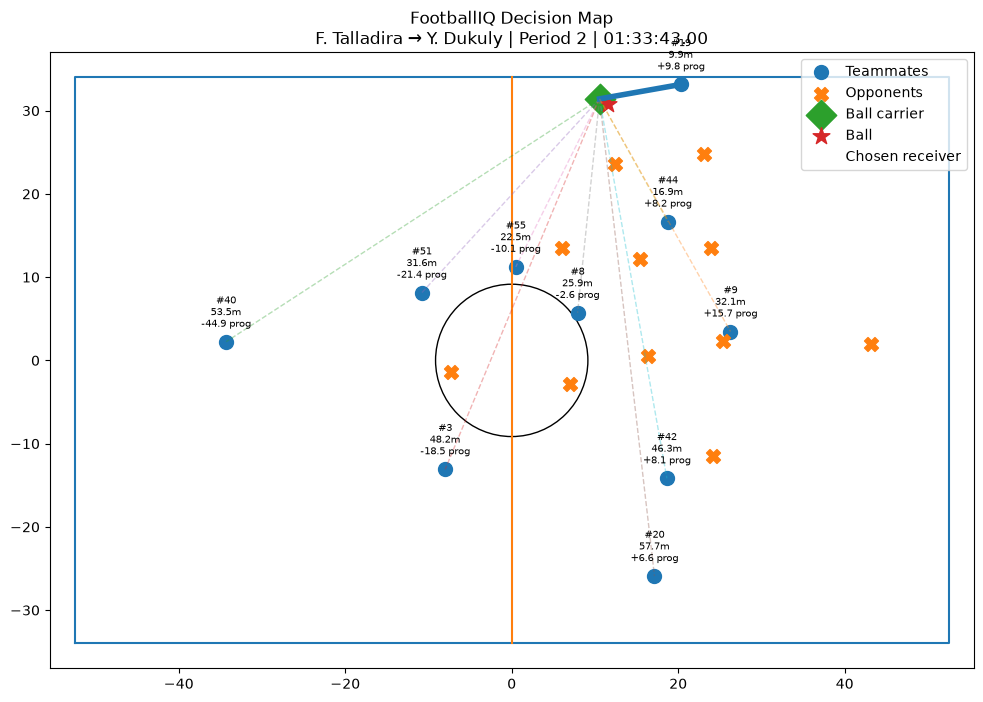

In [141]:
fig, ax = plt.subplots(figsize=(12, 8))

# ============================================================
# CAMPO
# ============================================================

pitch_length = 105
pitch_width = 68

x_min = -pitch_length / 2
x_max = pitch_length / 2
y_min = -pitch_width / 2
y_max = pitch_width / 2

# Bordo campo
ax.plot(
    [x_min, x_max, x_max, x_min, x_min],
    [y_min, y_min, y_max, y_max, y_min]
)

# Linea di metà campo
ax.plot(
    [0, 0],
    [y_min, y_max]
)

# Cerchio centrale
centre_circle = plt.Circle(
    (0, 0),
    9.15,
    fill=False
)

ax.add_patch(centre_circle)


# ============================================================
# GIOCATORI
# ============================================================

# Compagni
ax.scatter(
    decision_teammates["x"],
    decision_teammates["y"],
    s=100,
    marker="o",
    label="Teammates"
)

# Avversari
ax.scatter(
    decision_opponents["x"],
    decision_opponents["y"],
    s=100,
    marker="X",
    label="Opponents"
)

# Portatore
ax.scatter(
    decision_carrier["x"],
    decision_carrier["y"],
    s=240,
    marker="D",
    label="Ball carrier"
)

# Palla
decision_ball = decision_frame["ball_data"]

ax.scatter(
    decision_ball["x"],
    decision_ball["y"],
    s=160,
    marker="*",
    label="Ball"
)


# ============================================================
# TUTTI I CANDIDATE PASSES
# ============================================================

for _, candidate in decision_candidates.iterrows():

    # Passaggio realmente scelto
    if candidate["chosen"] == 1:

        line_style = "-"
        line_width = 4
        line_alpha = 1.0

    # Alternative non scelte
    else:

        line_style = "--"
        line_width = 1
        line_alpha = 0.35

    ax.plot(
        [decision_carrier["x"], candidate["x"]],
        [decision_carrier["y"], candidate["y"]],
        linestyle=line_style,
        linewidth=line_width,
        alpha=line_alpha
    )


# ============================================================
# ETICHETTE DEI CANDIDATI
# ============================================================

for _, candidate in decision_candidates.iterrows():

    label = (
        f"#{int(candidate['shirt_number'])}\n"
        f"{candidate['pass_distance']:.1f}m\n"
        f"+{candidate['forward_progression']:.1f} prog"
        if candidate["forward_progression"] >= 0
        else
        f"#{int(candidate['shirt_number'])}\n"
        f"{candidate['pass_distance']:.1f}m\n"
        f"{candidate['forward_progression']:.1f} prog"
    )

    ax.text(
        candidate["x"],
        candidate["y"] + 1.8,
        label,
        ha="center",
        fontsize=7
    )


# ============================================================
# EVIDENZIAMO IL RICEVENTE SCELTO
# ============================================================

chosen_candidate = decision_candidates[
    decision_candidates["chosen"] == 1
]

if len(chosen_candidate) == 1:

    chosen_candidate = chosen_candidate.iloc[0]

    ax.scatter(
        chosen_candidate["x"],
        chosen_candidate["y"],
        s=260,
        marker="o",
        facecolors="none",
        linewidths=2.5,
        label="Chosen receiver"
    )


# ============================================================
# IMPOSTAZIONI FINALI
# ============================================================

ax.set_xlim(x_min - 3, x_max + 3)
ax.set_ylim(y_min - 3, y_max + 3)

ax.set_aspect("equal")

ax.set_title(
    f"FootballIQ Decision Map\n"
    f"{decision_carrier['player_name']} → "
    f"{actual_receiver_name} | "
    f"Period {decision_frame['period']} | "
    f"{decision_frame['timestamp']}"
)

ax.legend()

plt.show()

In [142]:
%%writefile ../src/tracking_utils.py

import json
import pandas as pd


def get_tracking_frame(tracking_file, frame_number):
    """
    Cerca e restituisce un singolo frame dal file tracking JSONL.
    """

    with open(tracking_file, "r", encoding="utf-8") as f:

        for line in f:

            frame = json.loads(line)

            if frame["frame"] == frame_number:
                return frame

    return None

Writing ../src/tracking_utils.py


In [143]:
import sys

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

In [144]:
test_frame = get_tracking_frame(
    TRACKING_FILE,
    decision_frame_number
)

print("Frame:", test_frame["frame"])
print("Timestamp:", test_frame["timestamp"])
print("Players:", len(test_frame["player_data"]))

NameError: name 'get_tracking_frame' is not defined

In [145]:
from tracking_utils import get_tracking_frame

In [146]:
test_frame = get_tracking_frame(
    TRACKING_FILE,
    decision_frame_number
)

print("Frame:", test_frame["frame"])
print("Timestamp:", test_frame["timestamp"])
print("Players:", len(test_frame["player_data"]))

Frame: 57260
Timestamp: 01:33:43.00
Players: 22


In [147]:
%%writefile -a ../src/tracking_utils.py

def build_players_table(
    frame,
    players_metadata,
    team_lookup
):
    """
    Converte i player_data di un frame in una tabella
    arricchita con nome, squadra, numero e ruolo.
    """

    players_df = pd.DataFrame(
        frame["player_data"]
    )

    players = players_df.merge(
        players_metadata,
        on="player_id",
        how="left"
    )

    players["team_name"] = (
        players["team_id"]
        .map(team_lookup)
    )

    return players


Appending to ../src/tracking_utils.py


In [148]:
import importlib
import tracking_utils

importlib.reload(tracking_utils)

<module 'tracking_utils' from 'C:\\Users\\khalu\\OneDrive\\Desktop\\FootballIQ\\src\\tracking_utils.py'>

In [149]:
from tracking_utils import (
    get_tracking_frame,
    build_players_table
)

In [150]:
test_players = build_players_table(
    test_frame,
    players_metadata,
    team_lookup
)

test_players[
    [
        "player_name",
        "team_name",
        "shirt_number",
        "position",
        "x",
        "y"
    ]
].head()

,player_name,team_name,shirt_number,position,x,y
0,E. Cox,Adelaide United Football Club,40,Goalkeeper,-34.31,2.24
1,B. Vriends,Adelaide United Football Club,3,Right Center Back,-7.99,-13.08
2,P. Kikianis,Adelaide United Football Club,51,Left Center Back,-10.80,8.13
3,D. Pierias,Adelaide United Football Club,20,Right Back,17.15,-25.91
4,F. Talladira,Adelaide United Football Club,62,Left Back,10.55,31.42


In [151]:
%%writefile ../src/feature_engineering.py

import numpy as np
import pandas as pd


def get_attack_direction(team_players):
    """
    Stima la direzione d'attacco usando la posizione del portiere.

    Restituisce:
        +1 -> squadra attacca verso x positivo
        -1 -> squadra attacca verso x negativo
    """

    goalkeeper = team_players[
        team_players["position"].str.contains(
            "Goalkeeper",
            case=False,
            na=False
        )
    ]

    if len(goalkeeper) == 0:
        raise ValueError("Goalkeeper not found.")

    goalkeeper_x = goalkeeper.iloc[0]["x"]

    if goalkeeper_x < 0:
        return 1
    else:
        return -1


def nearest_defender_info(
    receiver_x,
    receiver_y,
    opponents
):
    """
    Trova l'avversario più vicino al possibile ricevente.
    """

    distances = np.sqrt(
        (opponents["x"] - receiver_x) ** 2
        +
        (opponents["y"] - receiver_y) ** 2
    )

    nearest_index = distances.idxmin()

    defender = opponents.loc[nearest_index]

    return pd.Series({
        "nearest_defender_name":
            defender["player_name"],

        "nearest_defender_distance":
            distances.loc[nearest_index]
    })


def passing_lane_features(
    carrier_x,
    carrier_y,
    receiver_x,
    receiver_y,
    opponents,
    lane_width=1.5
):
    """
    Misura quanto è ostruita la linea
    tra portatore e possibile ricevente.
    """

    dx = receiver_x - carrier_x
    dy = receiver_y - carrier_y

    segment_length_squared = dx**2 + dy**2

    if segment_length_squared == 0:

        return pd.Series({
            "lane_blockers": 0,
            "nearest_lane_defender_distance": np.nan
        })

    lane_distances = []

    for _, opponent in opponents.iterrows():

        px = opponent["x"] - carrier_x
        py = opponent["y"] - carrier_y

        # Proiezione dell'avversario
        # sul segmento portatore-ricevente
        t = (
            px * dx + py * dy
        ) / segment_length_squared

        # Consideriamo solo avversari
        # tra portatore e ricevente
        if 0 <= t <= 1:

            projection_x = carrier_x + t * dx
            projection_y = carrier_y + t * dy

            distance_to_lane = np.sqrt(
                (opponent["x"] - projection_x) ** 2
                +
                (opponent["y"] - projection_y) ** 2
            )

            lane_distances.append(
                distance_to_lane
            )

    if len(lane_distances) == 0:

        return pd.Series({
            "lane_blockers": 0,
            "nearest_lane_defender_distance": np.nan
        })

    lane_distances = np.array(
        lane_distances
    )

    blockers = np.sum(
        lane_distances <= lane_width
    )

    return pd.Series({
        "lane_blockers": int(blockers),
        "nearest_lane_defender_distance":
            lane_distances.min()
    })


def build_candidate_passes(
    players,
    carrier_player_id,
    lane_width=1.5
):
    """
    Dato uno stato del gioco, costruisce
    le possibili opzioni di passaggio del portatore
    e calcola le principali feature spaziali.
    """

    # ----------------------------
    # PORTATORE
    # ----------------------------

    carrier_df = players[
        players["player_id"] == carrier_player_id
    ]

    if len(carrier_df) == 0:
        raise ValueError("Ball carrier not found.")

    carrier = carrier_df.iloc[0]

    carrier_team_id = carrier["team_id"]


    # ----------------------------
    # COMPAGNI E AVVERSARI
    # ----------------------------

    teammates = players[
        (players["team_id"] == carrier_team_id)
        &
        (players["player_id"] != carrier_player_id)
    ].copy()

    opponents = players[
        players["team_id"] != carrier_team_id
    ].copy()


    # ----------------------------
    # DIREZIONE D'ATTACCO
    # ----------------------------

    team_players = players[
        players["team_id"] == carrier_team_id
    ]

    attack_direction = get_attack_direction(
        team_players
    )


    # ----------------------------
    # CANDIDATE PASSES
    # ----------------------------

    candidates = teammates.copy()


    # Distanza del passaggio
    candidates["pass_distance"] = np.sqrt(
        (candidates["x"] - carrier["x"]) ** 2
        +
        (candidates["y"] - carrier["y"]) ** 2
    )


    # Progressione verso la porta avversaria
    candidates["forward_progression"] = (
        attack_direction
        *
        (candidates["x"] - carrier["x"])
    )


    # Difensore più vicino
    defender_info = candidates.apply(
        lambda row: nearest_defender_info(
            row["x"],
            row["y"],
            opponents
        ),
        axis=1
    )

    candidates[
        [
            "nearest_defender_name",
            "nearest_defender_distance"
        ]
    ] = defender_info


    # Passing lane
    lane_info = candidates.apply(
        lambda row: passing_lane_features(
            carrier["x"],
            carrier["y"],
            row["x"],
            row["y"],
            opponents,
            lane_width
        ),
        axis=1
    )

    candidates[
        [
            "lane_blockers",
            "nearest_lane_defender_distance"
        ]
    ] = lane_info


    return candidates

Writing ../src/feature_engineering.py


In [152]:
import feature_engineering
import importlib

importlib.reload(feature_engineering)

from feature_engineering import build_candidate_passes

In [153]:
decision_players_test = build_players_table(
    decision_frame,
    players_metadata,
    team_lookup
)

In [154]:
decision_candidates_test = build_candidate_passes(
    decision_players_test,
    decision_possession_player_id
)

In [155]:
decision_candidates_test[
    [
        "player_name",
        "shirt_number",
        "pass_distance",
        "forward_progression",
        "nearest_defender_name",
        "nearest_defender_distance",
        "lane_blockers",
        "nearest_lane_defender_distance"
    ]
].sort_values(
    "forward_progression",
    ascending=False
)

,player_name,shirt_number,pass_distance,forward_progression,nearest_defender_name,nearest_defender_distance,lane_blockers,nearest_lane_defender_distance
10,L. Jovanovic,9,32.072346,15.73,K. Shaw,1.480034,0.0,2.278705
9,Y. Dukuly,19,9.921986,9.77,C. Hollman,8.800619,0.0,8.076629
7,R. White,44,16.880954,8.21,Léo Sena,5.594006,0.0,2.242160
8,A. Ayoubi,42,46.302227,8.09,J. Courtney-Perkins,6.198903,3.0,0.299182
3,D. Pierias,20,57.708655,6.60,J. Courtney-Perkins,16.077889,1.0,0.906841
6,Isaias,8,25.855135,-2.64,A. Segecic,8.015997,0.0,2.615094
5,E. Alagich,55,22.548525,-10.06,A. Segecic,5.970209,0.0,3.945287
1,B. Vriends,3,48.207692,-18.54,Douglas Costa,11.747996,0.0,2.714032
2,P. Kikianis,51,31.595041,-21.35,Douglas Costa,10.091680,0.0,6.666420
0,E. Cox,40,53.515344,-44.86,Douglas Costa,27.207885,0.0,7.597903


In [156]:
%%writefile ../src/event_processing.py

import json
import pandas as pd


def get_decision_frame_number(
    possession_row,
    end_frame_column
):
    """
    Restituisce il frame immediatamente precedente
    alla fine della player possession.
    """

    end_frame = possession_row[end_frame_column]

    if pd.isna(end_frame):
        return None

    return int(end_frame) - 1


def find_next_possession_player(
    tracking_file,
    decision_frame_number,
    current_player_id,
    player_lookup,
    window_frames=50
):
    """
    Cerca il primo giocatore diverso dal portatore
    che viene identificato in possesso dopo il decision frame.

    window_frames=50 significa circa 5 secondi
    con tracking a 10 fps.
    """

    with open(tracking_file, "r", encoding="utf-8") as f:

        for line in f:

            frame = json.loads(line)

            # Ignoriamo i frame precedenti
            if frame["frame"] <= decision_frame_number:
                continue

            # Stop dopo la finestra scelta
            if frame["frame"] > decision_frame_number + window_frames:
                break

            player_id = frame["possession"]["player_id"]

            # Nessun possessore identificato
            if player_id is None:
                continue

            # È ancora il portatore originale
            if player_id == current_player_id:
                continue

            player_info = player_lookup.get(
                player_id,
                {}
            )

            return {
                "frame": frame["frame"],
                "timestamp": frame["timestamp"],
                "player_id": player_id,
                "player_name": player_info.get("player_name"),
                "team_id": player_info.get("team_id"),
                "shirt_number": player_info.get("shirt_number")
            }

    return None

Writing ../src/event_processing.py


In [157]:
import event_processing
import importlib

importlib.reload(event_processing)

from event_processing import (
    get_decision_frame_number,
    find_next_possession_player
)

In [158]:
automatic_decision_frame_number = get_decision_frame_number(
    full_sample_possession,
    end_frame_column
)

print(
    "Automatic decision frame:",
    automatic_decision_frame_number
)

print(
    "Previous manual decision frame:",
    decision_frame_number
)

Automatic decision frame: 57260
Previous manual decision frame: 57260


In [159]:
player_lookup = (
    players_metadata
    .set_index("player_id")
    [
        [
            "player_name",
            "team_id",
            "shirt_number"
        ]
    ]
    .to_dict("index")
)

In [160]:
{
    931987: {
        "player_name": "H. Devenish-Meares",
        "team_id": 869,
        "shirt_number": 12
    },

    ...
}

SyntaxError: ':' expected after dictionary key (1283139884.py, line 8)

In [161]:
automatic_next_player = find_next_possession_player(
    TRACKING_FILE,
    automatic_decision_frame_number,
    decision_possession_player_id,
    player_lookup,
    window_frames=50
)

automatic_next_player

{'frame': 57271,
 'timestamp': '01:33:44.10',
 'player_id': 50971,
 'player_name': 'Y. Dukuly',
 'team_id': 866,
 'shirt_number': 19}

In [162]:
# Squadra del portatore
carrier_team_id = decision_carrier["team_id"]

# Classifichiamo ciò che succede dopo la decisione
if automatic_next_player is None:

    choice_status = "unresolved"
    actual_receiver_id = None
    actual_receiver_name = None

elif automatic_next_player["team_id"] == carrier_team_id:

    choice_status = "same_team_new_possession"

    actual_receiver_id = automatic_next_player["player_id"]
    actual_receiver_name = automatic_next_player["player_name"]

else:

    choice_status = "possession_lost"

    actual_receiver_id = None
    actual_receiver_name = None


print("Choice status:", choice_status)
print("Actual receiver ID:", actual_receiver_id)
print("Actual receiver:", actual_receiver_name)

Choice status: same_team_new_possession
Actual receiver ID: 50971
Actual receiver: Y. Dukuly


In [163]:
if actual_receiver_id is not None:

    receiver_found = (
        decision_candidates_test["player_id"]
        == actual_receiver_id
    ).any()

    print(
        "Actual receiver among candidate passes:",
        receiver_found
    )

else:
    print("No confirmed same-team receiver.")

Actual receiver among candidate passes: True


In [164]:
decision_options = decision_candidates_test.copy()

decision_options["chosen"] = 0

In [165]:
if actual_receiver_id is not None:

    decision_options.loc[
        decision_options["player_id"] == actual_receiver_id,
        "chosen"
    ] = 1

In [166]:
decision_options[
    [
        "player_name",
        "shirt_number",
        "pass_distance",
        "forward_progression",
        "nearest_defender_distance",
        "lane_blockers",
        "nearest_lane_defender_distance",
        "chosen"
    ]
].sort_values(
    ["chosen", "forward_progression"],
    ascending=[False, False]
)

,player_name,shirt_number,pass_distance,forward_progression,nearest_defender_distance,lane_blockers,nearest_lane_defender_distance,chosen
9,Y. Dukuly,19,9.921986,9.77,8.800619,0.0,8.076629,1
10,L. Jovanovic,9,32.072346,15.73,1.480034,0.0,2.278705,0
7,R. White,44,16.880954,8.21,5.594006,0.0,2.242160,0
8,A. Ayoubi,42,46.302227,8.09,6.198903,3.0,0.299182,0
3,D. Pierias,20,57.708655,6.60,16.077889,1.0,0.906841,0
6,Isaias,8,25.855135,-2.64,8.015997,0.0,2.615094,0
5,E. Alagich,55,22.548525,-10.06,5.970209,0.0,3.945287,0
1,B. Vriends,3,48.207692,-18.54,11.747996,0.0,2.714032,0
2,P. Kikianis,51,31.595041,-21.35,10.091680,0.0,6.666420,0
0,E. Cox,40,53.515344,-44.86,27.207885,0.0,7.597903,0


In [167]:
%%writefile ../src/pipeline.py

import pandas as pd

from tracking_utils import (
    get_tracking_frame,
    build_players_table
)

from feature_engineering import (
    build_candidate_passes
)

from event_processing import (
    get_decision_frame_number,
    find_next_possession_player
)


def process_possession(
    possession_row,
    end_frame_column,
    tracking_file,
    players_metadata,
    team_lookup,
    player_lookup,
    window_frames=50
):
    """
    Processa una singola player_possession.

    Restituisce una tabella:
    una riga per ogni possibile ricevente,
    con feature spaziali e scelta osservata.

    La scelta è ancora PROVVISORIA:
    same-team next possession viene usato come proxy
    del ricevente reale.
    """

    # -------------------------------------------------
    # 1. TROVIAMO IL DECISION FRAME
    # -------------------------------------------------

    decision_frame_number = get_decision_frame_number(
        possession_row,
        end_frame_column
    )

    if decision_frame_number is None:
        return None


    # -------------------------------------------------
    # 2. RECUPERIAMO IL TRACKING
    # -------------------------------------------------

    frame = get_tracking_frame(
        tracking_file,
        decision_frame_number
    )

    if frame is None:
        return None


    # -------------------------------------------------
    # 3. IDENTIFICHIAMO IL PORTATORE
    # -------------------------------------------------

    carrier_player_id = frame["possession"]["player_id"]

    if carrier_player_id is None:
        return None


    # -------------------------------------------------
    # 4. COSTRUIAMO LA TABELLA DEI 22 GIOCATORI
    # -------------------------------------------------

    players = build_players_table(
        frame,
        players_metadata,
        team_lookup
    )

    carrier_df = players[
        players["player_id"] == carrier_player_id
    ]

    if len(carrier_df) == 0:
        return None

    carrier = carrier_df.iloc[0]

    carrier_team_id = carrier["team_id"]


    # -------------------------------------------------
    # 5. GENERIAMO LE ALTERNATIVE DI PASSAGGIO
    # -------------------------------------------------

    try:

        candidates = build_candidate_passes(
            players,
            carrier_player_id
        )

    except Exception:
        return None


    # -------------------------------------------------
    # 6. TROVIAMO IL PRIMO NUOVO POSSESSORE
    # -------------------------------------------------

    next_player = find_next_possession_player(
        tracking_file,
        decision_frame_number,
        carrier_player_id,
        player_lookup,
        window_frames=window_frames
    )


    # -------------------------------------------------
    # 7. CLASSIFICHIAMO IL RISULTATO
    # -------------------------------------------------

    actual_receiver_id = None
    actual_receiver_name = None

    if next_player is None:

        choice_status = "unresolved"

    elif next_player["team_id"] == carrier_team_id:

        choice_status = "same_team_new_possession"

        actual_receiver_id = next_player["player_id"]
        actual_receiver_name = next_player["player_name"]

    else:

        choice_status = "possession_lost"


    # -------------------------------------------------
    # 8. AGGIUNGIAMO LA SCELTA OSSERVATA
    # -------------------------------------------------

    candidates = candidates.copy()

    candidates["chosen"] = 0

    if actual_receiver_id is not None:

        candidates.loc[
            candidates["player_id"] == actual_receiver_id,
            "chosen"
        ] = 1


    # -------------------------------------------------
    # 9. AGGIUNGIAMO INFORMAZIONI SULLA DECISIONE
    # -------------------------------------------------

    candidates["event_id"] = possession_row["event_id"]

    candidates["decision_frame"] = decision_frame_number

    candidates["carrier_id"] = carrier_player_id
    candidates["carrier_name"] = carrier["player_name"]

    candidates["carrier_team_id"] = carrier_team_id

    candidates["choice_status"] = choice_status

    candidates["actual_receiver_id"] = actual_receiver_id
    candidates["actual_receiver_name"] = actual_receiver_name


    return candidates

Writing ../src/pipeline.py


In [168]:
import pipeline
import importlib

importlib.reload(pipeline)

from pipeline import process_possession

In [169]:
test_decision = process_possession(
    possession_row=full_sample_possession,
    end_frame_column=end_frame_column,
    tracking_file=TRACKING_FILE,
    players_metadata=players_metadata,
    team_lookup=team_lookup,
    player_lookup=player_lookup
)

In [170]:
type(test_decision)

pandas.DataFrame

In [171]:
test_decision[
    [
        "event_id",
        "carrier_name",
        "player_name",
        "pass_distance",
        "forward_progression",
        "nearest_defender_distance",
        "lane_blockers",
        "chosen",
        "choice_status"
    ]
]

,event_id,carrier_name,player_name,pass_distance,forward_progression,nearest_defender_distance,lane_blockers,chosen,choice_status
0,8_1001,F. Talladira,E. Cox,53.515344,-44.86,27.207885,0.0,0,same_team_new_possession
1,8_1001,F. Talladira,B. Vriends,48.207692,-18.54,11.747996,0.0,0,same_team_new_possession
2,8_1001,F. Talladira,P. Kikianis,31.595041,-21.35,10.091680,0.0,0,same_team_new_possession
3,8_1001,F. Talladira,D. Pierias,57.708655,6.60,16.077889,1.0,0,same_team_new_possession
5,8_1001,F. Talladira,E. Alagich,22.548525,-10.06,5.970209,0.0,0,same_team_new_possession
6,8_1001,F. Talladira,Isaias,25.855135,-2.64,8.015997,0.0,0,same_team_new_possession
7,8_1001,F. Talladira,R. White,16.880954,8.21,5.594006,0.0,0,same_team_new_possession
8,8_1001,F. Talladira,A. Ayoubi,46.302227,8.09,6.198903,3.0,0,same_team_new_possession
9,8_1001,F. Talladira,Y. Dukuly,9.921986,9.77,8.800619,0.0,1,same_team_new_possession
10,8_1001,F. Talladira,L. Jovanovic,32.072346,15.73,1.480034,0.0,0,same_team_new_possession


In [172]:
test_results = []

# Prendiamo le prime 5 possessioni che hanno
# un valore disponibile per il frame finale
test_possessions = player_possessions[
    player_possessions[end_frame_column].notna()
].head(5)

for _, possession in test_possessions.iterrows():

    result = process_possession(
        possession_row=possession,
        end_frame_column=end_frame_column,
        tracking_file=TRACKING_FILE,
        players_metadata=players_metadata,
        team_lookup=team_lookup,
        player_lookup=player_lookup
    )

    # Alcune possessioni potrebbero non essere processabili
    if result is not None:
        test_results.append(result)

print("Possessions tested:", len(test_possessions))
print("Possessions successfully processed:", len(test_results))

Possessions tested: 5
Possessions successfully processed: 1


In [173]:
if len(test_results) > 0:

    test_dataset = pd.concat(
        test_results,
        ignore_index=True
    )

    print("Dataset shape:", test_dataset.shape)

else:

    test_dataset = pd.DataFrame()

    print("No possessions processed.")

Dataset shape: (10, 24)


In [174]:
test_dataset[
    [
        "event_id",
        "decision_frame",
        "carrier_name",
        "player_name",
        "pass_distance",
        "forward_progression",
        "nearest_defender_distance",
        "lane_blockers",
        "chosen",
        "choice_status"
    ]
].head(30)

,event_id,decision_frame,carrier_name,player_name,pass_distance,forward_progression,nearest_defender_distance,lane_blockers,chosen,choice_status
0,8_1,136,E. Cox,B. Vriends,16.480719,16.29,6.636279,0.0,0,unresolved
1,8_1,136,E. Cox,P. Kikianis,14.787082,14.43,0.822982,1.0,0,unresolved
2,8_1,136,E. Cox,D. Pierias,27.141363,27.06,4.934136,0.0,0,unresolved
3,8_1,136,E. Cox,F. Talladira,31.107404,23.75,10.281488,0.0,0,unresolved
4,8_1,136,E. Cox,E. Alagich,33.783869,32.47,5.191580,1.0,0,unresolved
5,8_1,136,E. Cox,J. Barnett,21.630927,21.59,8.212825,0.0,0,unresolved
6,8_1,136,E. Cox,S. Mauk,37.732262,34.20,2.199204,0.0,0,unresolved
7,8_1,136,E. Cox,Z. Clough,40.604859,40.55,2.169539,1.0,0,unresolved
8,8_1,136,E. Cox,J. Yull,46.953301,37.06,7.882417,0.0,0,unresolved
9,8_1,136,E. Cox,A. Goodwin,48.008510,44.67,4.688027,1.0,0,unresolved


In [175]:
test_dataset["event_id"].nunique()

1

In [176]:
test_dataset.groupby("event_id").size()

event_id
8_1    10
dtype: int64

In [177]:
test_dataset[
    [
        "event_id",
        "choice_status"
    ]
].drop_duplicates()["choice_status"].value_counts()

choice_status
unresolved    1
Name: count, dtype: int64

In [178]:
diagnostics = []

test_possessions = player_possessions[
    player_possessions[end_frame_column].notna()
].head(5)


for _, possession in test_possessions.iterrows():

    info = {
        "event_id": possession["event_id"]
    }

    try:

        # 1. Decision frame
        decision_number = get_decision_frame_number(
            possession,
            end_frame_column
        )

        info["decision_frame"] = decision_number

        if decision_number is None:
            info["result"] = "no_decision_frame"
            diagnostics.append(info)
            continue


        # 2. Tracking frame
        frame = get_tracking_frame(
            TRACKING_FILE,
            decision_number
        )

        if frame is None:
            info["result"] = "tracking_frame_not_found"
            diagnostics.append(info)
            continue


        info["n_players"] = len(
            frame["player_data"]
        )


        # 3. Portatore
        carrier_id = frame["possession"]["player_id"]

        info["carrier_id"] = carrier_id

        if carrier_id is None:
            info["result"] = "no_carrier_in_decision_frame"
            diagnostics.append(info)
            continue


        # 4. Costruiamo giocatori
        players = build_players_table(
            frame,
            players_metadata,
            team_lookup
        )


        carrier_df = players[
            players["player_id"] == carrier_id
        ]

        if len(carrier_df) == 0:
            info["result"] = "carrier_not_in_player_table"
            diagnostics.append(info)
            continue


        carrier = carrier_df.iloc[0]

        info["carrier_name"] = carrier["player_name"]
        info["carrier_team_id"] = carrier["team_id"]


        # 5. Candidate passes
        try:

            candidates = build_candidate_passes(
                players,
                carrier_id
            )

            info["n_candidates"] = len(candidates)

        except Exception as e:

            info["result"] = (
                "candidate_error: "
                + type(e).__name__
                + " - "
                + str(e)
            )

            diagnostics.append(info)
            continue


        # 6. Nuovo possessore
        next_player = find_next_possession_player(
            TRACKING_FILE,
            decision_number,
            carrier_id,
            player_lookup,
            window_frames=50
        )


        if next_player is None:

            info["next_player"] = None
            info["choice_status"] = "unresolved"

        else:

            info["next_player"] = next_player["player_name"]
            info["next_team_id"] = next_player["team_id"]

            if next_player["team_id"] == carrier["team_id"]:
                info["choice_status"] = "same_team_new_possession"
            else:
                info["choice_status"] = "possession_lost"


        info["result"] = "processed"

        diagnostics.append(info)


    except Exception as e:

        info["result"] = (
            "unexpected_error: "
            + type(e).__name__
            + " - "
            + str(e)
        )

        diagnostics.append(info)


diagnostics_df = pd.DataFrame(diagnostics)

diagnostics_df

,event_id,decision_frame,n_players,carrier_id,result,carrier_name,carrier_team_id,n_candidates,next_player,choice_status
0,8_0,94,22,NaN,no_carrier_in_decision_frame,NaN,NaN,NaN,NaN,NaN
1,8_1,136,22,809070.0,processed,E. Cox,866.0,10.0,NaN,unresolved
2,8_2,169,22,NaN,no_carrier_in_decision_frame,NaN,NaN,NaN,NaN,NaN
3,8_3,188,22,NaN,no_carrier_in_decision_frame,NaN,NaN,NaN,NaN,NaN
4,8_4,206,22,NaN,no_carrier_in_decision_frame,NaN,NaN,NaN,NaN,NaN


In [179]:
%%writefile -a ../src/event_processing.py


def find_carrier_near_frame(
    tracking_file,
    target_frame,
    lookback_frames=10
):
    """
    Cerca il giocatore in possesso nel target frame.
    Se non è disponibile, guarda indietro fino a
    lookback_frames.

    Con tracking a 10 fps:
    10 frame ≈ 1 secondo.
    """

    best_match = None

    start_frame = max(
        0,
        target_frame - lookback_frames
    )

    with open(
        tracking_file,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            frame = json.loads(line)

            frame_number = frame["frame"]

            # Non ci interessa ciò che viene prima
            if frame_number < start_frame:
                continue

            # Ci fermiamo oltre il target
            if frame_number > target_frame:
                break

            player_id = frame["possession"]["player_id"]

            # Ogni volta che troviamo un possessore valido,
            # lo salviamo.
            # Alla fine rimarrà quello più vicino al target.
            if player_id is not None:

                best_match = {
                    "player_id": player_id,
                    "frame": frame_number,
                    "timestamp": frame["timestamp"],
                    "group": frame["possession"]["group"]
                }

    return best_match

Appending to ../src/event_processing.py


In [180]:
import importlib
import event_processing

importlib.reload(event_processing)

from event_processing import (
    get_decision_frame_number,
    find_next_possession_player,
    find_carrier_near_frame
)

In [181]:
carrier_tests = []

for _, possession in test_possessions.iterrows():

    decision_number = get_decision_frame_number(
        possession,
        end_frame_column
    )

    carrier_info = find_carrier_near_frame(
        TRACKING_FILE,
        decision_number,
        lookback_frames=10
    )

    carrier_tests.append({
        "event_id": possession["event_id"],
        "decision_frame": decision_number,
        "carrier_info": carrier_info
    })

pd.DataFrame(carrier_tests)

,event_id,decision_frame,carrier_info
0,8_0,94,None
1,8_1,136,"{'player_id': 809070, 'frame': 136, 'timestamp..."
2,8_2,169,None
3,8_3,188,None
4,8_4,206,None


In [182]:
check_columns = [
    "event_id",
    "frame_start",
    "frame_end",
    "player_id",
    "player_name",
    "team_id",
    "player_targeted_id",
    "player_targeted_name",
    "player_targeted_x_pass",
    "player_targeted_y_pass",
    "player_targeted_x_reception",
    "player_targeted_y_reception"
]

player_possessions[
    [c for c in check_columns if c in player_possessions.columns]
].head(10)

,event_id,frame_start,frame_end,player_id,player_name,team_id,player_targeted_id,player_targeted_name,player_targeted_x_pass,player_targeted_y_pass,player_targeted_x_reception,player_targeted_y_reception
0,8_0,95,95,560893,E. Alagich,866,809070.0,E. Cox,-37.88,0.47,-38.05,0.63
2,8_1,118,137,809070,E. Cox,866,51686.0,A. Goodwin,18.60,16.94,NaN,NaN
6,8_2,170,170,998256,K. Shaw,869,25534.0,A. Ouahim,-14.08,-5.91,NaN,NaN
7,8_3,189,189,51005,D. Pierias,866,51686.0,A. Goodwin,31.65,11.12,NaN,NaN
8,8_4,207,207,28293,Léo Sena,869,25534.0,A. Ouahim,-13.68,-0.67,NaN,NaN
10,8_5,214,214,50959,S. Mauk,866,51686.0,A. Goodwin,25.75,8.17,NaN,NaN
13,8_6,270,279,50959,S. Mauk,866,51686.0,A. Goodwin,26.63,6.40,NaN,NaN
20,8_7,292,292,28293,Léo Sena,869,51000.0,J. Courtney-Perkins,-23.30,4.88,-23.33,7.81
23,8_8,302,322,51000,J. Courtney-Perkins,869,17231.0,P. Klimala,0.89,3.00,NaN,NaN
25,8_9,374,382,809070,E. Cox,866,26766.0,B. Vriends,-29.72,-20.98,-31.55,-19.34


In [183]:
pass_attempts = player_possessions[
    player_possessions["player_targeted_id"].notna()
].copy()

pass_attempts["pass_completed"] = (
    pass_attempts["player_targeted_x_reception"].notna()
    &
    pass_attempts["player_targeted_y_reception"].notna()
)

print("Player possessions:", len(player_possessions))
print("Pass attempts:", len(pass_attempts))
print()
print(pass_attempts["pass_completed"].value_counts())

pass_attempts[
    [
        "event_id",
        "frame_end",
        "player_name",
        "player_targeted_name",
        "pass_completed"
    ]
].head(20)

Player possessions: 1005
Pass attempts: 878

pass_completed
True     741
False    137
Name: count, dtype: int64


,event_id,frame_end,player_name,player_targeted_name,pass_completed
0,8_0,95,E. Alagich,E. Cox,True
2,8_1,137,E. Cox,A. Goodwin,False
6,8_2,170,K. Shaw,A. Ouahim,False
7,8_3,189,D. Pierias,A. Goodwin,False
8,8_4,207,Léo Sena,A. Ouahim,False
10,8_5,214,S. Mauk,A. Goodwin,False
13,8_6,279,S. Mauk,A. Goodwin,False
20,8_7,292,Léo Sena,J. Courtney-Perkins,True
23,8_8,322,J. Courtney-Perkins,P. Klimala,False
25,8_9,382,E. Cox,B. Vriends,True


In [184]:
passing_options = events[
    events["event_type"] == "passing_option"
].copy()

print("Passing option events:", len(passing_options))

passing_options[
    [
        "event_id",
        "associated_player_possession_event_id",
        "player_id",
        "player_name",
        "peak_passing_option_frame",
        "passing_option_score",
        "xpass_completion",
        "xthreat"
    ]
].head(20)

Passing option events: 2626


,event_id,associated_player_possession_event_id,player_id,player_name,peak_passing_option_frame,passing_option_score,xpass_completion,xthreat
3,7_0,8_1,51686,A. Goodwin,137.0,0.8867,0.8286,0.0012
4,7_1,8_1,51646,J. Yull,136.0,0.8996,0.8120,0.0013
5,7_2,8_1,50959,S. Mauk,134.0,0.8536,0.7851,0.0011
14,7_3,8_6,51646,J. Yull,279.0,0.8664,0.5237,0.0079
15,7_4,8_6,560893,E. Alagich,272.0,0.6542,0.7714,0.0027
16,7_5,8_6,973078,F. Talladira,272.0,0.7869,0.7662,0.0024
17,7_6,8_6,51686,A. Goodwin,279.0,0.7589,0.4262,0.0156
21,7_7,8_7,51000,J. Courtney-Perkins,292.0,0.8724,0.9570,0.0008
24,7_8,8_8,17231,P. Klimala,322.0,0.8511,0.4691,0.0050
27,7_9,8_10,809070,E. Cox,394.0,0.9533,0.9981,0.0000


In [185]:
sample_pass = pass_attempts.iloc[0]

print("Carrier:", sample_pass["player_name"])
print("Chosen target:", sample_pass["player_targeted_name"])
print("Completed:", sample_pass["pass_completed"])

Carrier: E. Alagich
Chosen target: E. Cox
Completed: True


In [186]:
sample_options = passing_options[
    passing_options["associated_player_possession_event_id"]
    == sample_pass["event_id"]
].copy()

sample_options["chosen"] = (
    sample_options["player_id"]
    == sample_pass["player_targeted_id"]
).astype(int)

sample_options[
    [
        "player_name",
        "passing_option_score",
        "xpass_completion",
        "xthreat",
        "chosen"
    ]
].sort_values(
    "chosen",
    ascending=False
)

,player_name,passing_option_score,xpass_completion,xthreat,chosen


In [187]:
sample_options = passing_options[
    passing_options["associated_player_possession_event_id"]
    == sample_pass["event_id"]
].copy()

sample_options["chosen"] = (
    sample_options["player_id"]
    == sample_pass["player_targeted_id"]
).astype(int)

sample_options[
    [
        "player_name",
        "passing_option_score",
        "xpass_completion",
        "xthreat",
        "chosen"
    ]
].sort_values(
    "chosen",
    ascending=False
)

,player_name,passing_option_score,xpass_completion,xthreat,chosen


In [188]:
# Normalizziamo gli ID per evitare problemi di tipo o spazi
pass_attempts["event_id_norm"] = (
    pass_attempts["event_id"]
    .astype(str)
    .str.strip()
)

passing_options["associated_possession_id_norm"] = (
    passing_options["associated_player_possession_event_id"]
    .astype(str)
    .str.strip()
)

# Troviamo gli event_id presenti in ENTRAMBE le tabelle
linked_pass_ids = sorted(
    set(pass_attempts["event_id_norm"])
    &
    set(
        passing_options[
            "associated_possession_id_norm"
        ].dropna()
    )
)

print("Pass attempts:", len(pass_attempts))
print("Passing options:", len(passing_options))
print("Passes with linked passing options:", len(linked_pass_ids))

print("\nFirst linked IDs:")
print(linked_pass_ids[:10])

Pass attempts: 878
Passing options: 2626
Passes with linked passing options: 826

First linked IDs:
['8_1', '8_10', '8_100', '8_1000', '8_1001', '8_101', '8_102', '8_103', '8_104', '8_105']


In [189]:
sample_pass_id = linked_pass_ids[0]

sample_pass = pass_attempts[
    pass_attempts["event_id_norm"] == sample_pass_id
].iloc[0]

sample_options = passing_options[
    passing_options["associated_possession_id_norm"]
    == sample_pass_id
].copy()

print("Event ID:", sample_pass_id)
print("Carrier:", sample_pass["player_name"])
print("Target:", sample_pass["player_targeted_name"])
print("Completed:", sample_pass["pass_completed"])
print("Number of passing options:", len(sample_options))

Event ID: 8_1
Carrier: E. Cox
Target: A. Goodwin
Completed: False
Number of passing options: 3


In [190]:
sample_options["chosen"] = (
    sample_options["player_id"]
    == sample_pass["player_targeted_id"]
).astype(int)

In [191]:
sample_options[
    [
        "player_name",
        "passing_option_score",
        "xpass_completion",
        "xthreat",
        "chosen"
    ]
].sort_values(
    "chosen",
    ascending=False
)

,player_name,passing_option_score,xpass_completion,xthreat,chosen
3,A. Goodwin,0.8867,0.8286,0.0012,1
4,J. Yull,0.8996,0.8120,0.0013,0
5,S. Mauk,0.8536,0.7851,0.0011,0


In [192]:
# ============================================================
# PREPARIAMO I PASSAGGI REALI
# ============================================================

passes_for_merge = pass_attempts[
    [
        "event_id_norm",
        "player_id",
        "player_name",
        "team_id",
        "player_targeted_id",
        "player_targeted_name",
        "pass_completed"
    ]
].copy()

# Rinominiamo per evitare confusione dopo il merge
passes_for_merge = passes_for_merge.rename(
    columns={
        "player_id": "carrier_id",
        "player_name": "carrier_name",
        "team_id": "carrier_team_id",
        "player_targeted_id": "actual_receiver_id",
        "player_targeted_name": "actual_receiver_name"
    }
)


# ============================================================
# PREPARIAMO LE PASSING OPTIONS
# ============================================================

options_for_merge = passing_options.copy()

options_for_merge = options_for_merge.rename(
    columns={
        "player_id": "option_player_id",
        "player_name": "option_player_name"
    }
)


# ============================================================
# MERGE
# ============================================================

decision_dataset_base = options_for_merge.merge(
    passes_for_merge,
    left_on="associated_possession_id_norm",
    right_on="event_id_norm",
    how="inner"
)


# ============================================================
# IDENTIFICHIAMO LA SCELTA REALE
# ============================================================

decision_dataset_base["chosen"] = (
    decision_dataset_base["option_player_id"]
    ==
    decision_dataset_base["actual_receiver_id"]
).astype(int)


print("Rows:", len(decision_dataset_base))
print(
    "Decisions:",
    decision_dataset_base["event_id_norm"].nunique()
)

decision_dataset_base[
    [
        "event_id_norm",
        "carrier_name",
        "option_player_name",
        "actual_receiver_name",
        "passing_option_score",
        "xpass_completion",
        "xthreat",
        "pass_completed",
        "chosen"
    ]
].head(30)

Rows: 2393
Decisions: 826


,event_id_norm,carrier_name,option_player_name,actual_receiver_name,passing_option_score,xpass_completion,xthreat,pass_completed,chosen
0,8_1,E. Cox,A. Goodwin,A. Goodwin,0.8867,0.8286,0.0012,False,1
1,8_1,E. Cox,J. Yull,A. Goodwin,0.8996,0.8120,0.0013,False,0
2,8_1,E. Cox,S. Mauk,A. Goodwin,0.8536,0.7851,0.0011,False,0
3,8_6,S. Mauk,J. Yull,A. Goodwin,0.8664,0.5237,0.0079,False,0
4,8_6,S. Mauk,E. Alagich,A. Goodwin,0.6542,0.7714,0.0027,False,0
5,8_6,S. Mauk,F. Talladira,A. Goodwin,0.7869,0.7662,0.0024,False,0
6,8_6,S. Mauk,A. Goodwin,A. Goodwin,0.7589,0.4262,0.0156,False,1
7,8_7,Léo Sena,J. Courtney-Perkins,J. Courtney-Perkins,0.8724,0.9570,0.0008,True,1
8,8_8,J. Courtney-Perkins,P. Klimala,P. Klimala,0.8511,0.4691,0.0050,False,1
9,8_10,B. Vriends,E. Cox,P. Kikianis,0.9533,0.9981,0.0000,True,0


In [193]:
choice_check = (
    decision_dataset_base
    .groupby("event_id_norm")["chosen"]
    .sum()
)

choice_check.value_counts().sort_index()

chosen
0      1
1    813
2     12
Name: count, dtype: int64

In [194]:
valid_event_ids = choice_check[
    choice_check == 1
].index

decision_dataset = decision_dataset_base[
    decision_dataset_base["event_id_norm"].isin(
        valid_event_ids
    )
].copy()

print(
    "Valid decisions:",
    decision_dataset["event_id_norm"].nunique()
)

print(
    "Total candidate options:",
    len(decision_dataset)
)

print(
    "Chosen options:",
    decision_dataset["chosen"].sum()
)

Valid decisions: 813
Total candidate options: 2339
Chosen options: 813


In [195]:
valid_event_ids = choice_check[
    choice_check == 1
].index

decision_dataset = decision_dataset_base[
    decision_dataset_base["event_id_norm"].isin(
        valid_event_ids
    )
].copy()

print(
    "Valid decisions:",
    decision_dataset["event_id_norm"].nunique()
)

print(
    "Total candidate options:",
    len(decision_dataset)
)

print(
    "Chosen options:",
    decision_dataset["chosen"].sum()
)

Valid decisions: 813
Total candidate options: 2339
Chosen options: 813


In [196]:
options_per_decision = (
    decision_dataset
    .groupby("event_id_norm")
    .size()
)

print(
    "Average options per decision:",
    options_per_decision.mean()
)

print(
    "Median options per decision:",
    options_per_decision.median()
)

print(
    "Minimum:",
    options_per_decision.min()
)

print(
    "Maximum:",
    options_per_decision.max()
)

Average options per decision: 2.8769987699876998
Median options per decision: 3.0
Minimum: 1
Maximum: 8


In [197]:
decision_dataset.groupby("chosen")[
    [
        "passing_option_score",
        "xpass_completion",
        "xthreat"
    ]
].mean()

,passing_option_score,xpass_completion,xthreat
chosen,,,
0,0.798949,0.823551,0.009187
1,0.852336,0.857804,0.009160


In [198]:
# Controlli rapidi
print("Decisioni:", decision_dataset["event_id_norm"].nunique())
print("Opzioni totali:", len(decision_dataset))
print("Scelte reali:", decision_dataset["chosen"].sum())

print("\nMissing values principali:")
print(
    decision_dataset[
        ["passing_option_score", "xpass_completion", "xthreat", "chosen"]
    ].isna().sum()
)

# Salviamo il dataset
OUTPUT_FILE = PROJECT_ROOT / "data" / "processed" / "footballiq_decisions.csv"

decision_dataset.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nSalvato in:", OUTPUT_FILE)

Decisioni: 813
Opzioni totali: 2339
Scelte reali: 813

Missing values principali:
passing_option_score    0
xpass_completion        0
xthreat                 0
chosen                  0
dtype: int64

Salvato in: C:\Users\khalu\OneDrive\Desktop\FootballIQ\data\processed\footballiq_decisions.csv


In [199]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.4 MB 10.2 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.4 MB 11.4 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.4 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 10.7 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   -- ------------------------------------- 2.4/37.4 MB 12.4 MB/s eta 0:00:03
   ----- ---------------------------------- 5.0/37.4 MB 12.3 MB/s eta 0:00:03
   ------- -------------------------------- 7.3/37.4 MB 12.3 MB/s eta 0:00:03
   ---------- ----------------------------- 10.0/37.4 MB 12.3 MB/s eta 0:00:03
   ------------- -------------------------- 12.3/37.4 MB 12.3 MB/s eta 0:00:03
   --------------- ------------------------ 14.9/37.4 MB 12.3 MB/s eta 0:00:02
   ------------------ --------------------- 17.6/37.4 MB 12.3 MB/s eta 0:00:02
   ---

In [200]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit

In [201]:
features = [
    "passing_option_score",
    "xpass_completion",
    "xthreat"
]

X = decision_dataset[features]
y = decision_dataset["chosen"]

groups = decision_dataset["event_id_norm"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_data = decision_dataset.iloc[train_idx].copy()
test_data = decision_dataset.iloc[test_idx].copy()

print("Train decisions:", train_data["event_id_norm"].nunique())
print("Test decisions:", test_data["event_id_norm"].nunique())

Train decisions: 650
Test decisions: 163


In [202]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=1000
    ))
])

model.fit(
    X_train,
    y_train
)

test_probabilities = model.predict_proba(
    X_test
)[:, 1]

auc = roc_auc_score(
    y_test,
    test_probabilities
)

print("ROC-AUC:", round(auc, 3))

ROC-AUC: 0.711


In [203]:
# Copiamo il test set
test_scored = test_data.copy()

# Probabilità prevista che ogni opzione venga scelta
test_scored["predicted_choice_probability"] = test_probabilities

# Per ogni decisione, il modello sceglie l'opzione
# con probabilità più alta
predicted_indices = (
    test_scored
    .groupby("event_id_norm")["predicted_choice_probability"]
    .idxmax()
)

predicted_choices = test_scored.loc[predicted_indices]

# Accuracy: quante volte l'opzione prevista
# coincide con quella realmente scelta?
top1_accuracy = predicted_choices["chosen"].mean()

print("ROC-AUC:", round(auc, 3))
print("Top-1 choice accuracy:", round(top1_accuracy, 3))


ROC-AUC: 0.711
Top-1 choice accuracy: 0.656


In [204]:
decision_dataset["expected_threat_value"] = (
    decision_dataset["xpass_completion"]
    *
    decision_dataset["xthreat"]
)

In [205]:
best_option_indices = (
    decision_dataset
    .groupby("event_id_norm")["expected_threat_value"]
    .idxmax()
)

best_options = (
    decision_dataset
    .loc[best_option_indices]
    [
        [
            "event_id_norm",
            "option_player_id",
            "option_player_name",
            "expected_threat_value"
        ]
    ]
    .rename(
        columns={
            "option_player_id": "best_option_id",
            "option_player_name": "best_option_name",
            "expected_threat_value": "best_option_value"
        }
    )
)

In [206]:
chosen_options = (
    decision_dataset[
        decision_dataset["chosen"] == 1
    ]
    [
        [
            "event_id_norm",
            "carrier_id",
            "carrier_name",
            "actual_receiver_id",
            "actual_receiver_name",
            "expected_threat_value",
            "xpass_completion",
            "xthreat"
        ]
    ]
    .rename(
        columns={
            "expected_threat_value": "chosen_option_value"
        }
    )
)

In [207]:
decision_summary = chosen_options.merge(
    best_options,
    on="event_id_norm",
    how="inner"
)

decision_summary["decision_gap"] = (
    decision_summary["best_option_value"]
    -
    decision_summary["chosen_option_value"]
)

decision_summary["model_best_option_chosen"] = (
    decision_summary["actual_receiver_id"]
    ==
    decision_summary["best_option_id"]
).astype(int)

decision_summary.head()

,event_id_norm,carrier_id,carrier_name,actual_receiver_id,actual_receiver_name,chosen_option_value,xpass_completion,xthreat,best_option_id,best_option_name,best_option_value,decision_gap,model_best_option_chosen
0,8_1,809070,E. Cox,51686.0,A. Goodwin,0.000994,0.8286,0.0012,51646,J. Yull,0.001056,0.000061,0
1,8_6,50959,S. Mauk,51686.0,A. Goodwin,0.006649,0.4262,0.0156,51686,A. Goodwin,0.006649,0.000000,1
2,8_7,28293,Léo Sena,51000.0,J. Courtney-Perkins,0.000766,0.9570,0.0008,51000,J. Courtney-Perkins,0.000766,0.000000,1
3,8_8,51000,J. Courtney-Perkins,17231.0,P. Klimala,0.002345,0.4691,0.0050,17231,P. Klimala,0.002345,0.000000,1
4,8_10,26766,B. Vriends,809759.0,P. Kikianis,0.000000,0.9953,0.0000,809070,E. Cox,0.000000,0.000000,0


In [208]:
player_summary = (
    decision_summary
    .groupby(
        ["carrier_id", "carrier_name"]
    )
    .agg(
        decisions=("event_id_norm", "count"),
        model_best_choice_rate=("model_best_option_chosen", "mean"),
        average_decision_gap=("decision_gap", "mean"),
        median_decision_gap=("decision_gap", "median"),
        average_chosen_value=("chosen_option_value", "mean")
    )
    .reset_index()
)

# Evitiamo ranking su giocatori con pochissime decisioni
player_summary = player_summary[
    player_summary["decisions"] >= 10
].copy()

player_summary = player_summary.sort_values(
    "average_decision_gap"
)

player_summary.head(20)

,carrier_id,carrier_name,decisions,model_best_choice_rate,average_decision_gap,median_decision_gap,average_chosen_value
4,26766,B. Vriends,42,0.666667,0.000233,0.000000,0.001826
24,809070,E. Cox,21,0.428571,0.000310,0.000027,0.000358
26,931987,H. Devenish-Meares,27,0.407407,0.000359,0.000076,0.000225
25,809759,P. Kikianis,48,0.541667,0.000403,0.000000,0.002480
13,51644,R. Grant,51,0.352941,0.000636,0.000278,0.000774
29,998256,K. Shaw,32,0.406250,0.001051,0.000662,0.001013
6,42513,Z. Clough,27,0.407407,0.001669,0.000172,0.009492
7,50949,J. Barnett,32,0.406250,0.001685,0.000295,0.002822
28,973078,F. Talladira,33,0.303030,0.001872,0.000868,0.002398
20,560895,Isaias,18,0.555556,0.002212,0.000000,0.005269


In [209]:
DECISION_SUMMARY_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "footballiq_decision_summary.csv"
)

PLAYER_SUMMARY_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "footballiq_player_summary.csv"
)

decision_summary.to_csv(
    DECISION_SUMMARY_FILE,
    index=False
)

player_summary.to_csv(
    PLAYER_SUMMARY_FILE,
    index=False
)

print("Saved:")
print(DECISION_SUMMARY_FILE)
print(PLAYER_SUMMARY_FILE)

Saved:
C:\Users\khalu\OneDrive\Desktop\FootballIQ\data\processed\footballiq_decision_summary.csv
C:\Users\khalu\OneDrive\Desktop\FootballIQ\data\processed\footballiq_player_summary.csv
